# DAFTER full training-run report

Inspect a DAFTER run end to end: artifact inventory, saved configuration, training/validation curves, checkpoint loading, architecture and parameter diagnostics, learned hidden-feature frequency gains, checkpoint evolution, logged validation audio, and optional fresh MIDI-conditioned sampling.

The notebook defaults to `dafter_runs/dafter_guitarv5` and its latest checkpoint. Change `RUN_NAME` for a later training, or set it to `None` to select the most recently modified DAFTER run automatically. Run with the repository's `after` kernel. Only the optional fresh-sampling section needs `DB_PATHS`; the complete artifact/log/checkpoint report works from the run folder alone.

In [1]:
from __future__ import annotations

import io
import math
import os
import re
import sys
from contextlib import nullcontext
from pathlib import Path

# Find the repository whether Jupyter starts in the root or after_scripts/.
candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next((p for p in candidates if (p / 'after' / '__init__.py').is_file()), None)
if ROOT is None:
    raise RuntimeError('Could not find the AFTER repository root')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

os.environ.setdefault('MPLCONFIGDIR', f'/tmp/matplotlib-after-{os.getuid()}')

import gin
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
import torch
from IPython.display import Audio, Markdown, display
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

from after.dafter import (DafterNetwork, DafterRectifiedFlow,
                          SpectralStyleEncoder, collate_dafter,
                          get_dafter_datasets)

plt.rcParams.update({'figure.figsize': (11, 4), 'figure.dpi': 110})
print('Repository:', ROOT)
print('PyTorch:', torch.__version__, '| CUDA available:', torch.cuda.is_available())

Repository: /slow-2/nils/repos/AFTER
PyTorch: 2.5.1+cu124 | CUDA available: True


## Settings

`CHECKPOINT_STEP = None` selects the largest numbered checkpoint. `RUN_NAME = None` selects the run whose checkpoint/config was modified most recently. Fresh samples use the same initial noise for every value in `SAMPLE_STEPS`, making solver-step comparisons meaningful. The original database path is a command-line argument and is not saved in `config.gin`, so add it to `DB_PATHS` only when needed.

In [3]:
RUN_NAME = 'dafter_guitarv7'  # set None to auto-select the newest run
CHECKPOINT_STEP = None       # e.g. 25000; None means latest
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SAMPLE_STEPS = (50, 20,)
NUM_EXAMPLES = 3
EXAMPLE_SEED = 4             # dataset indices and crop positions
NOISE_SEED = 2026            # rectified-flow initial noise
USE_AMP = False              # set True for faster CUDA sampling if desired

# Fresh sampling only. Multiple LMDBs are allowed. You can alternatively
# export DAFTER_DB_PATH=/path/to/database before starting Jupyter.
DB_PATHS = ["/fast-1/nils/guitar_audio_midi"]
if not DB_PATHS and os.environ.get('DAFTER_DB_PATH'):
    DB_PATHS = os.environ['DAFTER_DB_PATH'].split(os.pathsep)

RUNS_ROOT = ROOT / 'dafter_runs'
available_runs = sorted(
    (path for path in RUNS_ROOT.iterdir()
     if path.is_dir() and (path / 'config.gin').is_file()),
    key=lambda path: path.name)
if not available_runs:
    raise FileNotFoundError(f'No DAFTER runs under {RUNS_ROOT}')
if RUN_NAME is None:
    def run_mtime(path):
        artifacts = [path / 'config.gin', *path.glob('checkpoint*.pt')]
        return max(item.stat().st_mtime for item in artifacts if item.exists())
    RUN_DIR = max(available_runs, key=run_mtime)
else:
    RUN_DIR = RUNS_ROOT / RUN_NAME
RUN_DIR = RUN_DIR.resolve()
assert (RUN_DIR / 'config.gin').is_file(), RUN_DIR
print('Available runs:', ', '.join(path.name for path in available_runs))
print('Selected run:', RUN_DIR)
print('Device:', DEVICE)
print('Fresh-sampling databases:', DB_PATHS or '(not set)')

Available runs: dafter_guitar, dafter_guitarv2, dafter_guitarv3, dafter_guitarv4, dafter_guitarv5, dafter_guitarv6, dafter_guitarv7
Selected run: /slow-2/nils/repos/AFTER/dafter_runs/dafter_guitarv7
Device: cuda
Fresh-sampling databases: ['/fast-1/nils/guitar_audio_midi']


## Run and artifact inventory

This table makes incomplete saves and stale logs visible. The latest event step may be newer than the latest checkpoint when training is still running or stopped between save intervals.

In [4]:
def numbered_step(path: Path) -> int:
    match = re.fullmatch(r'checkpoint(\d+)\.pt', path.name)
    return int(match.group(1)) if match else -1

run_rows = []
for run_path in available_runs:
    checkpoints = sorted(run_path.glob('checkpoint*.pt'), key=numbered_step)
    events = list(run_path.rglob('events.out.tfevents.*'))
    run_rows.append({
        'run': run_path.name, 'checkpoints': len(checkpoints),
        'latest_checkpoint': numbered_step(checkpoints[-1]) if checkpoints else None,
        'checkpoint_GB': sum(p.stat().st_size for p in checkpoints) / 1e9,
        'event_files': len(events),
        'events_MB': sum(p.stat().st_size for p in events) / 1e6})
display(pd.DataFrame(run_rows).set_index('run').round(3))

selected_checkpoints = sorted(RUN_DIR.glob('checkpoint*.pt'), key=numbered_step)
artifact_rows = [{
    'artifact': path.name, 'step': numbered_step(path),
    'size_MB': path.stat().st_size / 1e6,
    'modified': pd.Timestamp(path.stat().st_mtime, unit='s')}
    for path in selected_checkpoints]
artifact_table = pd.DataFrame(artifact_rows).set_index('artifact')
artifact_table['size_MB'] = artifact_table['size_MB'].round(3)
display(artifact_table)
display(Markdown('### Saved gin configuration'))
display(Markdown('```gin\n' + (RUN_DIR / 'config.gin').read_text() + '\n```'))

,checkpoints,latest_checkpoint,checkpoint_GB,event_files,events_MB
run,,,,,
dafter_guitar,40,1000000,1.363,4,160.002
dafter_guitarv2,40,1000000,4.861,3,317.287
dafter_guitarv3,24,600000,2.708,7,192.377
dafter_guitarv4,4,100000,0.502,2,34.912
dafter_guitarv5,15,375000,2.145,11,158.659
dafter_guitarv6,3,75000,0.424,3,25.384
dafter_guitarv7,10,250000,1.414,3,75.392


,step,size_MB,modified
artifact,,,
checkpoint25000.pt,25000,141.404,2026-09-02 15:05:10.119785309
checkpoint50000.pt,50000,141.406,2026-09-02 17:04:08.542482376
checkpoint75000.pt,75000,141.406,2026-09-02 18:57:13.628213644
checkpoint100000.pt,100000,141.406,2026-09-02 20:50:23.489904165
checkpoint125000.pt,125000,141.406,2026-09-02 22:43:29.507627487
checkpoint150000.pt,150000,141.406,2026-09-03 00:36:50.565221786
checkpoint175000.pt,175000,141.406,2026-09-03 02:30:04.630876064
checkpoint200000.pt,200000,141.406,2026-09-03 04:23:17.996536255
checkpoint225000.pt,225000,141.406,2026-09-03 06:16:30.102207422


### Saved gin configuration

```gin
from __gin__ import dynamic_registration
import after.dafter.data
import after.dafter.model as after2
import after.dafter.network as after3
import after.dafter.style as after4
import after.dafter.trainer as after5

# Macros:
# ==============================================================================
BATCH_SIZE = 4
HOP_SIZE = 64
MAX_STEPS = 1000000
N_FRAMES = 1024
NFFT = 512
SPECTRAL_BINS = 256
SR = 44100
STFT_ALPHA = 1.0
STFT_BETA = 1.0
STYLE_CHANNELS = 64
STYLE_CONDITION_SOURCE = 'none'
STYLE_CROP_SAMPLES = 131072
STYLE_EMBEDDING_KEY = None

# Parameters for after.dafter.data.collate_dafter:
# ==============================================================================
after.dafter.data.collate_dafter.hop_size = %HOP_SIZE
after.dafter.data.collate_dafter.n_frames = %N_FRAMES
after.dafter.data.collate_dafter.sample_rate = %SR
after.dafter.data.collate_dafter.style_condition_source = %STYLE_CONDITION_SOURCE
after.dafter.data.collate_dafter.style_crop_samples = %STYLE_CROP_SAMPLES
after.dafter.data.collate_dafter.style_embedding_dim = %STYLE_CHANNELS
after.dafter.data.collate_dafter.style_embedding_key = %STYLE_EMBEDDING_KEY

# Parameters for after3.DafterNetwork:
# ==============================================================================
after3.DafterNetwork.attention_context_frames = 276
after3.DafterNetwork.condition_width = 128
after3.DafterNetwork.hidden_channels = 384
after3.DafterNetwork.hop_size = %HOP_SIZE
after3.DafterNetwork.max_batch_size = 1
after3.DafterNetwork.max_flow_steps = 20
after3.DafterNetwork.max_stream_frames = 16
after3.DafterNetwork.max_training_frames = %N_FRAMES
after3.DafterNetwork.midi_channels = 128
after3.DafterNetwork.mlp_multiplier = 2
after3.DafterNetwork.n_heads = 12
after3.DafterNetwork.n_layers = 8
after3.DafterNetwork.nfft = %NFFT
after3.DafterNetwork.patch_channels = 32
after3.DafterNetwork.patch_ratio = 16
after3.DafterNetwork.patch_time_kernel = 3
after3.DafterNetwork.stft_alpha = %STFT_ALPHA
after3.DafterNetwork.stft_beta = %STFT_BETA
after3.DafterNetwork.style_channels = %STYLE_CHANNELS
after3.DafterNetwork.use_flex_attention = True
after3.DafterNetwork.whiten_spectrum = True

# Parameters for after2.DafterRectifiedFlow:
# ==============================================================================
after2.DafterRectifiedFlow.freeze_style_encoder = False
after2.DafterRectifiedFlow.midi_dropout = 0.1
after2.DafterRectifiedFlow.style_condition_source = %STYLE_CONDITION_SOURCE
after2.DafterRectifiedFlow.style_dropout = 0.0

# Parameters for after5.DafterTrainer:
# ==============================================================================
after5.DafterTrainer.gradient_clip = 10.0
after5.DafterTrainer.learning_rate = 0.0001
after5.DafterTrainer.weight_decay = 0.0

# Parameters for after5.DafterTrainer.fit:
# ==============================================================================
after5.DafterTrainer.fit.max_steps = %MAX_STEPS
after5.DafterTrainer.fit.max_validation_batches = 50
after5.DafterTrainer.fit.sample_rate = %SR
after5.DafterTrainer.fit.steps_display = 100
after5.DafterTrainer.fit.steps_save = 25000
after5.DafterTrainer.fit.steps_valid = 5000
after5.DafterTrainer.fit.validation_audio_examples = 4
after5.DafterTrainer.fit.validation_sample_steps = [5, 20]

# Parameters for after.dafter.data.get_dafter_datasets:
# ==============================================================================
after.dafter.data.get_dafter_datasets.style_condition_source = \
    %STYLE_CONDITION_SOURCE
after.dafter.data.get_dafter_datasets.style_embedding_key = %STYLE_EMBEDDING_KEY
after.dafter.data.get_dafter_datasets.validation_size = 0.02

```

## Training curves

Repeated steps from restarted event files are resolved by keeping the most recently written value at each step.

Scalar tags: ['train/flow_loss', 'train/loss', 'train/midi_drop_fraction', 'train/style_drop_fraction', 'validation/flow_loss', 'validation/loss', 'validation/midi_drop_fraction', 'validation/style_drop_fraction']
Audio tags: ['audio/target/0', 'audio/target/1', 'audio/generated_5_steps/0', 'audio/generated_5_steps/1', 'audio/generated_20_steps/0', 'audio/generated_20_steps/1'] ...


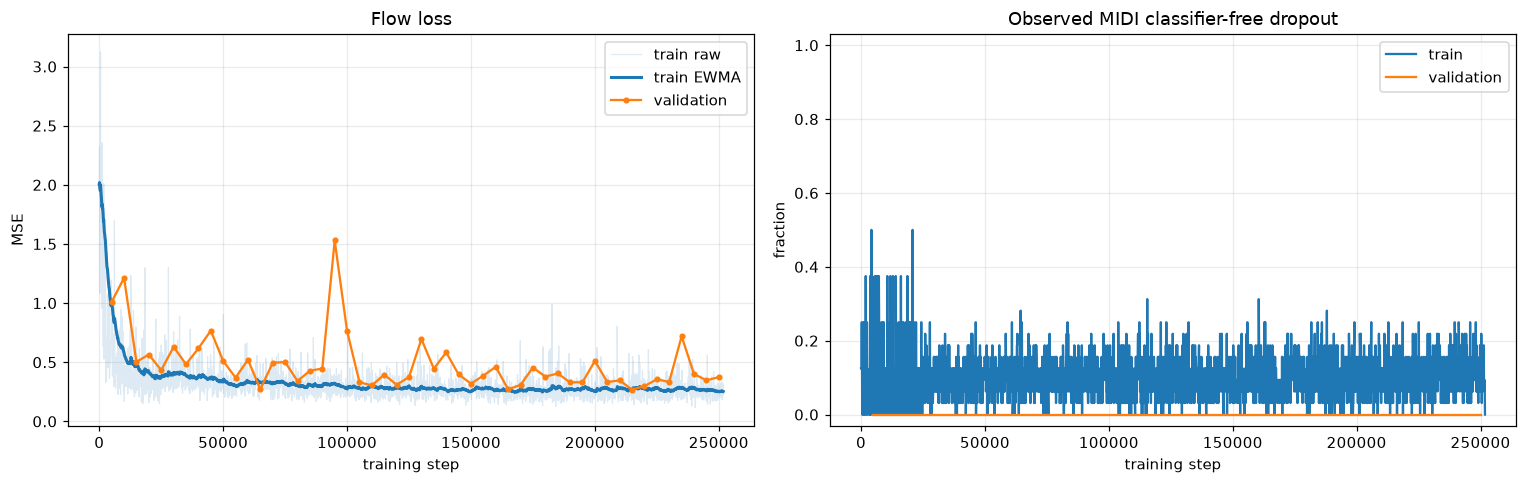

,points,first_step,last_step,latest,best,best_step,finite
tag,,,,,,,
train/flow_loss,2519,1,251800,0.224063,0.114441,240500,True
train/loss,2519,1,251800,0.224063,0.114441,240500,True
train/midi_drop_fraction,2519,1,251800,0.000000,0.000000,251800,True
train/style_drop_fraction,2519,1,251800,0.000000,0.000000,251800,True
validation/flow_loss,50,5000,250000,0.374335,0.268497,215000,True
validation/loss,50,5000,250000,0.374335,0.268497,215000,True
validation/midi_drop_fraction,50,5000,250000,0.000000,0.000000,250000,True
validation/style_drop_fraction,50,5000,250000,0.000000,0.000000,250000,True


In [5]:
EVENT_DIR = RUN_DIR / 'logs' if (RUN_DIR / 'logs').is_dir() else RUN_DIR
event_accumulator = EventAccumulator(
    str(EVENT_DIR), size_guidance={'scalars': 0, 'audio': 0})
event_accumulator.Reload()
print('Scalar tags:', event_accumulator.Tags()['scalars'])
print('Audio tags:', event_accumulator.Tags()['audio'][:6], '...')

def scalar_frame(tag: str) -> pd.DataFrame:
    rows = [dict(step=e.step, value=e.value, wall_time=e.wall_time)
            for e in event_accumulator.Scalars(tag)]
    if not rows:
        return pd.DataFrame(columns=['step', 'value', 'wall_time'])
    return (pd.DataFrame(rows).sort_values('wall_time')
            .drop_duplicates('step', keep='last').sort_values('step'))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for tag, label in [('train/flow_loss', 'train'),
                   ('validation/flow_loss', 'validation')]:
    frame = scalar_frame(tag)
    if not frame.empty:
        if label == 'train':
            axes[0].plot(frame.step, frame.value, color='C0', alpha=.15,
                         linewidth=.8, label='train raw')
            smoothed = frame.value.ewm(span=min(50, len(frame)),
                                       adjust=False).mean()
            axes[0].plot(frame.step, smoothed, color='C0',
                         linewidth=2, label='train EWMA')
        else:
            axes[0].plot(frame.step, frame.value, 'o-', color='C1',
                         markersize=3, label='validation')
axes[0].set(title='Flow loss', xlabel='training step', ylabel='MSE')
axes[0].grid(alpha=.25); axes[0].legend()

for tag in ['train/midi_drop_fraction', 'validation/midi_drop_fraction']:
    frame = scalar_frame(tag)
    if not frame.empty:
        axes[1].plot(frame.step, frame.value, label=tag.split('/')[0])
axes[1].set(title='Observed MIDI classifier-free dropout',
            xlabel='training step', ylabel='fraction', ylim=(-.03, 1.03))
axes[1].grid(alpha=.25); axes[1].legend()
plt.tight_layout(); plt.show()

summary_rows = []
for tag in event_accumulator.Tags()['scalars']:
    frame = scalar_frame(tag)
    if not frame.empty:
        best_index = frame.value.idxmin() if 'loss' in tag else frame.index[-1]
        summary_rows.append({
            'tag': tag, 'points': len(frame),
            'first_step': int(frame.step.iloc[0]),
            'last_step': int(frame.step.iloc[-1]),
            'latest': float(frame.value.iloc[-1]),
            'best': float(frame.loc[best_index, 'value']),
            'best_step': int(frame.loc[best_index, 'step']),
            'finite': bool(np.isfinite(frame.value).all())})
training_summary = pd.DataFrame(summary_rows).set_index('tag')
display(training_summary.round(6))

## Reconstruct and load the model

This follows `train_dafter.py`: the saved gin config constructs the exact network and style mode, then the checkpoint's `model_state` is loaded strictly.

In [6]:
def checkpoint_step(path: Path) -> int:
    match = re.fullmatch(r'checkpoint(\d+)\.pt', path.name)
    return int(match.group(1)) if match else -1

checkpoint_paths = sorted(
    (p for p in RUN_DIR.glob('checkpoint*.pt') if checkpoint_step(p) >= 0),
    key=checkpoint_step)
if not checkpoint_paths:
    raise FileNotFoundError(f'No checkpoints in {RUN_DIR}')
if CHECKPOINT_STEP is None:
    CHECKPOINT_PATH = checkpoint_paths[-1]
else:
    CHECKPOINT_PATH = RUN_DIR / f'checkpoint{CHECKPOINT_STEP}.pt'
    if not CHECKPOINT_PATH.is_file():
        raise FileNotFoundError(CHECKPOINT_PATH)

gin.clear_config()
gin.parse_config_file(str(RUN_DIR / 'config.gin'))
STYLE_SOURCE = gin.query_parameter('%STYLE_CONDITION_SOURCE')
SR = int(gin.query_parameter('%SR'))
NFFT = int(gin.query_parameter('%NFFT'))
HOP_SIZE = int(gin.query_parameter('%HOP_SIZE'))
N_FRAMES = int(gin.query_parameter('%N_FRAMES'))

network = DafterNetwork(use_style=STYLE_SOURCE != 'none')
style_encoder = SpectralStyleEncoder() if STYLE_SOURCE == 'encode' else None
model = DafterRectifiedFlow(network=network, style_encoder=style_encoder)
payload = torch.load(CHECKPOINT_PATH, map_location='cpu', weights_only=False)
selected_state = payload['model_state']
saved_step = int(payload.get('step', checkpoint_step(CHECKPOINT_PATH)))
load_result = model.load_state_dict(selected_state, strict=True)
del payload
model = model.to(DEVICE).eval()

parameter_count = sum(p.numel() for p in model.parameters())
print(f'Loaded {CHECKPOINT_PATH.name} (saved step {saved_step:,})')
print(load_result)
print(f'{parameter_count:,} parameters | style={STYLE_SOURCE!r}')
print(f'{SR:,} Hz | nfft={NFFT} | hop={HOP_SIZE} | frames={N_FRAMES}')
print('STFT magnitude normalization:',
      f'alpha={model.network.time_transform.alpha_rescale},',
      f'beta={model.network.time_transform.beta_rescale}')
print('Spectrum whitening:', model.network.whiten_spectrum)
if model.network.whiten_spectrum:
    whitening_mean = model.network.spectrum_whitening_mean
    whitening_std = model.network.spectrum_whitening_std
    print('Whitening coefficient ranges:',
          f'mean=[{float(whitening_mean.min()):.5g}, {float(whitening_mean.max()):.5g}],',
          f'std=[{float(whitening_std.min()):.5g}, {float(whitening_std.max()):.5g}]')

# These helpers define the representation boundary used throughout this notebook.
# Every spectrum passed to the flow network is in whitened model coordinates.
def pack_model_spectrum(raw_spectrum: torch.Tensor) -> torch.Tensor:
    packed_spectrum = model.network.time_transform._pack_spec(raw_spectrum)
    return model.network.whiten(packed_spectrum)

def unpack_model_spectrum(model_spectrum: torch.Tensor) -> torch.Tensor:
    packed_spectrum = model.network.unwhiten(model_spectrum)
    return model.network.time_transform._unpack_spec(packed_spectrum)

Loaded checkpoint250000.pt (saved step 250,000)
<All keys matched successfully>
11,771,298 parameters | style='none'
44,100 Hz | nfft=512 | hop=64 | frames=1024
STFT magnitude normalization: alpha=1.0, beta=1.0
Spectrum whitening: True
Whitening coefficient ranges: mean=[-0.021525, 0.0040924], std=[0.0037691, 8.3737]


## Architecture and parameter report

The component table is computed from the loaded model rather than copied from `architecture.txt`. The feature-pyramid table verifies the current frequency-only patchifier and the concatenated skip entering every matching depatchifier block.

In [9]:
def parameter_component(name: str) -> str:
    if name.startswith('patcher.'):
        return 'patchifier'
    if name.startswith('depatcher.'):
        return 'depatchifier'
    if name.startswith('blocks.'):
        return 'transformer'
    if name.startswith(('noise_spe.', 'noise_condition.',
                        'scale_inp.', 'scale_out.')):
        return 'noise embedding + gains'
    if name.startswith(('token_condition_fusion.', 'style_projection.')):
        return 'conditioning fusion'
    return name.split('.', 1)[0]

component_counts = {}
for name, parameter in model.network.named_parameters():
    component = parameter_component(name)
    component_counts[component] = component_counts.get(component, 0) + parameter.numel()
component_table = pd.DataFrame([
    {'component': name, 'parameters': count,
     'percent': 100 * count / parameter_count}
    for name, count in component_counts.items()])
display(component_table.sort_values('parameters', ascending=False)
        .set_index('component').round(3))
print('Saved leaf-layer report:', RUN_DIR / 'architecture.txt')
print(f'Attention history: {model.network.context_frames} frames = '
      f'{model.network.context_frames * HOP_SIZE / SR * 1000:.1f} ms')

,parameters,percent
component,,
transformer,11031552,93.716
patchifier,263008,2.234
depatchifier,246722,2.096
conditioning fusion,196992,1.673
noise embedding + gains,33024,0.281


Saved leaf-layer report: /slow-2/nils/repos/AFTER/dafter_runs/dafter_guitarv7/architecture.txt
Attention history: 276 frames = 400.5 ms


### Checkpoint parameter diagnostics

Parameter-group L2 norms are a compact way to catch explosions, frozen components, or corrupt saves. This reads checkpoints one at a time on CPU and does not alter the selected model.

,learning_rate,patchifier,conditioning fusion,noise embedding + gains,transformer,depatchifier
step,,,,,,
25000,0.0001,18.05314,16.72521,11.89379,125.33186,18.06080
50000,0.0001,20.01815,26.22548,12.61130,140.41368,20.14617
75000,0.0001,21.77210,35.49414,12.90221,152.00418,21.81276
100000,0.0001,22.69849,43.71799,13.08769,161.41435,23.47198
125000,0.0001,23.36055,50.41203,13.20099,169.67835,25.21220
150000,0.0001,23.94470,55.32748,13.33782,177.28091,26.84277
175000,0.0001,24.57561,58.73267,13.53233,184.49610,28.14550
200000,0.0001,25.17643,61.38911,13.75454,191.48225,29.27782
225000,0.0001,25.75818,63.52289,13.98908,198.22956,30.31435


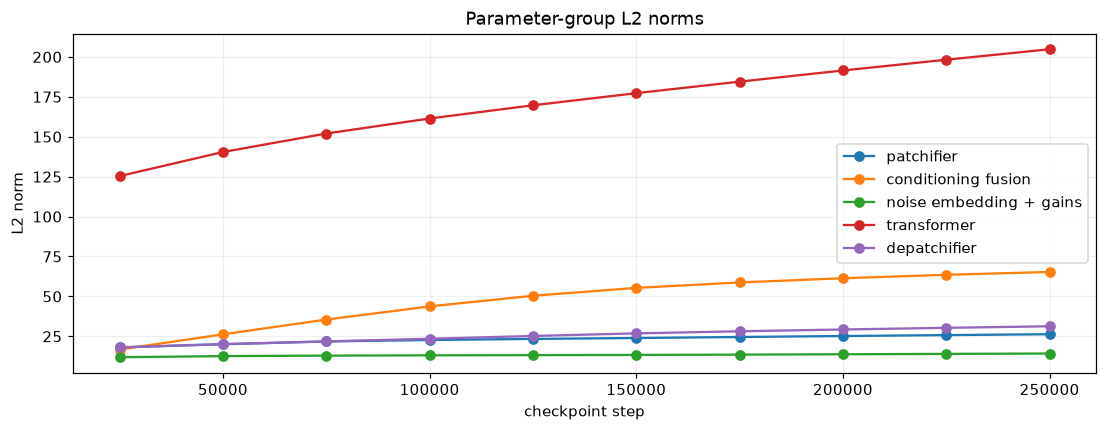

In [13]:
checkpoint_norm_rows = []
network_parameter_keys = {f'network.{name}'
                          for name, _ in model.network.named_parameters()}
for path in checkpoint_paths:
    checkpoint = torch.load(path, map_location='cpu', weights_only=False)
    squared_norms = {}
    for key, value in checkpoint['model_state'].items():
        if key not in network_parameter_keys or not torch.is_floating_point(value):
            continue
        component = parameter_component(key[len('network.'):])
        squared_norms[component] = squared_norms.get(component, 0.0) + (
            value.double().square().sum().item())
    optimizer_groups = checkpoint.get('optimizer_state', {}).get('param_groups', [])
    row = {'step': checkpoint_step(path),
           'learning_rate': optimizer_groups[0].get('lr', np.nan)
                            if optimizer_groups else np.nan}
    row.update({name: math.sqrt(value) for name, value in squared_norms.items()})
    checkpoint_norm_rows.append(row)
    del checkpoint
checkpoint_norms = pd.DataFrame(checkpoint_norm_rows).set_index('step')
display(checkpoint_norms.round(5))
checkpoint_norms.drop(columns='learning_rate', errors='ignore').plot(
    marker='o', figsize=(12, 4), title='Parameter-group L2 norms')
plt.xlabel('checkpoint step'); plt.ylabel('L2 norm'); plt.grid(alpha=.2)
plt.show()

## Audio helpers

In [15]:
def mono_numpy(waveform) -> np.ndarray:
    if torch.is_tensor(waveform):
        waveform = waveform.detach().float().cpu().numpy()
    waveform = np.asarray(waveform, dtype=np.float32)
    if waveform.ndim > 1:
        waveform = waveform.mean(axis=0)
    return waveform

def audio_stats(waveform) -> dict:
    x = mono_numpy(waveform)
    return {'peak': float(np.max(np.abs(x))),
            'rms': float(np.sqrt(np.mean(x * x))),
            'clip_%': float(100 * np.mean(np.abs(x) > 1))}

def show_audio(label: str, waveform, sample_rate: int):
    x = mono_numpy(waveform)
    stats = audio_stats(x)
    display(Markdown(f"**{label}** — peak {stats['peak']:.3f}, "
                     f"RMS {stats['rms']:.4f}, >1 {stats['clip_%']:.2f}%"))
    # Preserve relative level. Only the player copy is clipped for valid PCM playback.
    display(Audio(np.clip(x, -1, 1), rate=sample_rate, normalize=False))

def spectrogram_db(waveform, n_fft=2048, hop=256) -> np.ndarray:
    x = torch.as_tensor(mono_numpy(waveform))
    window = torch.hann_window(n_fft)
    spectrum = torch.stft(x, n_fft=n_fft, hop_length=hop,
                          window=window, return_complex=True)
    return (20 * torch.log10(spectrum.abs().clamp_min(1e-7))).numpy()

def plot_spectrogram_grid(examples, sample_rate: int, row_labels=None,
                          dynamic_range=90):
    # examples is rows of [(column_label, waveform), ...]
    specs = [[(label, spectrogram_db(wave)) for label, wave in row]
             for row in examples]
    global_max = max(spec.max() for row in specs for _, spec in row)
    rows, columns = len(specs), len(specs[0])
    fig, axes = plt.subplots(rows, columns, figsize=(4 * columns, 3 * rows),
                             squeeze=False, sharex=False, sharey=True)
    for row_index, row in enumerate(specs):
        for column_index, (label, spec) in enumerate(row):
            duration = (spec.shape[1] - 1) * 256 / sample_rate
            axis = axes[row_index, column_index]
            image = axis.imshow(spec, origin='lower', aspect='auto', cmap='magma',
                                vmin=global_max - dynamic_range, vmax=global_max,
                                extent=[0, duration, 0, sample_rate / 2000])
            axis.set_title(label); axis.set_xlabel('seconds')
            if column_index == 0:
                ylabel = 'frequency (kHz)'
                if row_labels is not None:
                    ylabel = f'{row_labels[row_index]}\n{ylabel}'
                axis.set_ylabel(ylabel)
    fig.colorbar(image, ax=axes, label='magnitude (dB)', shrink=.8)
    plt.show()

## Already-logged validation examples

This is the quickest qualitative check and needs no database path. It selects the latest validation step shared by all target/generated TensorBoard audio tags. Note that the logger clips generated signals to [−1, 1] before writing them, so use fresh sampling below for honest peak/clipping measurements.

In [16]:
audio_tags = event_accumulator.Tags()['audio']
target_tags = sorted(tag for tag in audio_tags if tag.startswith('audio/target/'))
generated_tags = sorted(tag for tag in audio_tags if tag.startswith('audio/generated_'))
logged_sample_steps = sorted({
    int(re.search(r'generated_(\d+)_steps', tag).group(1))
    for tag in generated_tags})
selected_tags = target_tags + generated_tags

def audio_event_steps(tag):
    return {event.step for event in event_accumulator.Audio(tag)}

common_steps = (set.intersection(
    *(audio_event_steps(tag) for tag in selected_tags))
    if selected_tags else set())
if not common_steps:
    print('No complete set of logged validation audio found; section skipped.')
    target_tags = []
    LOGGED_AUDIO_STEP = None
else:
    LOGGED_AUDIO_STEP = max(common_steps)

def read_logged_audio(tag: str, step: int):
    candidates = [e for e in event_accumulator.Audio(tag) if e.step == step]
    event = max(candidates, key=lambda e: e.wall_time)
    audio, rate = sf.read(io.BytesIO(event.encoded_audio_string),
                          dtype='float32', always_2d=True)
    return audio.T, rate

if LOGGED_AUDIO_STEP is not None:
    print(f'Using logged validation audio from step {LOGGED_AUDIO_STEP:,}')
logged_examples = []
for example_index in range(len(target_tags)):
    row = []
    tag_order = [f'audio/target/{example_index}'] + [
        f'audio/generated_{steps}_steps/{example_index}' for steps in logged_sample_steps]
    for tag in tag_order:
        waveform, rate = read_logged_audio(tag, LOGGED_AUDIO_STEP)
        row.append((tag.split('/')[1], waveform))
        show_audio(f'example {example_index} · {tag.split("/")[1]}', waveform, rate)
    logged_examples.append(row)

Using logged validation audio from step 250,000


**example 0 · target** — peak 0.348, RMS 0.0302, >1 0.00%

**example 0 · generated_5_steps** — peak 0.164, RMS 0.0154, >1 0.00%

**example 0 · generated_20_steps** — peak 0.294, RMS 0.0302, >1 0.00%

**example 1 · target** — peak 0.900, RMS 0.1386, >1 0.00%

...

**example 2 · generated_5_steps** — peak 0.202, RMS 0.0160, >1 0.00%

**example 2 · generated_20_steps** — peak 0.364, RMS 0.0363, >1 0.00%

**example 3 · target** — peak 0.642, RMS 0.1093, >1 0.00%

**example 3 · generated_5_steps** — peak 0.097, RMS 0.0152, >1 0.00%

**example 3 · generated_20_steps** — peak 0.150, RMS 0.0272, >1 0.00%

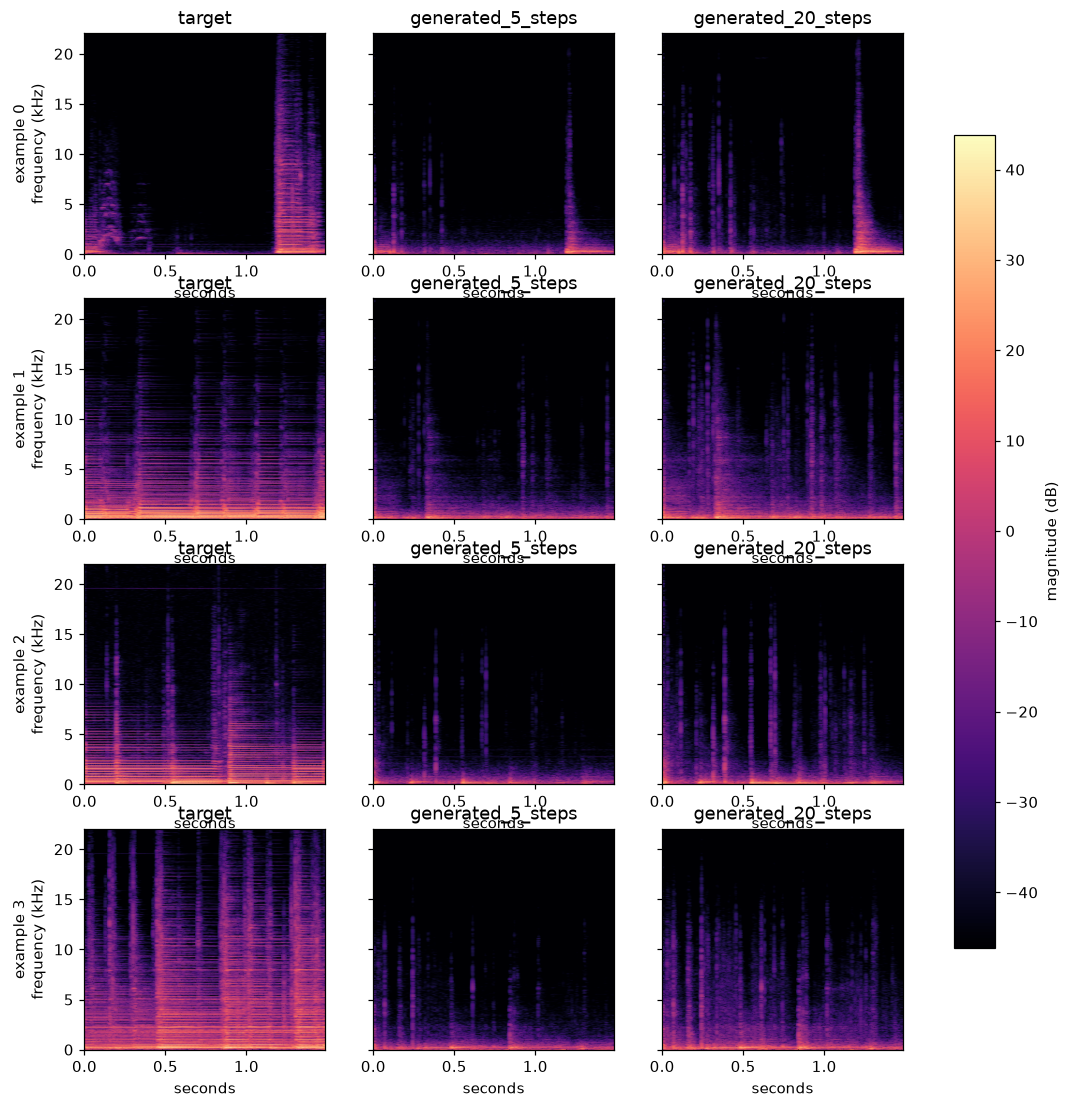

In [17]:
if logged_examples:
    plot_spectrogram_grid(
        logged_examples, rate,
        row_labels=[f'example {i}' for i in range(len(logged_examples))])
else:
    print('No logged spectrograms to plot.')

## Fresh dataset-conditioned sampling

Set `DB_PATHS` in the settings cell, rerun it, then run from here. Crops and initial noise are deterministic. The same noise tensor is reused for every solver-step count. Validation examples are preferred; if the split is empty, the full dataset is used.

In [18]:
fresh_batch = None
if not DB_PATHS:
    print('Fresh sampling skipped: set DB_PATHS in the settings cell.')
else:
    missing = [path for path in DB_PATHS if not Path(path).exists()]
    if missing:
        raise FileNotFoundError(f'Database paths do not exist: {missing}')
    train_dataset, valid_dataset, _, _ = get_dafter_datasets(
        db_list=[str(Path(p)) for p in DB_PATHS], use_cache=False,
        use_validation=True)
    eval_dataset = valid_dataset if valid_dataset is not None and len(valid_dataset) else train_dataset
    count = min(NUM_EXAMPLES, len(eval_dataset))
    rng = np.random.default_rng(EXAMPLE_SEED)
    example_indices = rng.choice(len(eval_dataset), size=count, replace=False).tolist()

    numpy_state = np.random.get_state()
    try:
        np.random.seed(EXAMPLE_SEED)
        fresh_batch = collate_dafter([eval_dataset[i] for i in example_indices])
    finally:
        np.random.set_state(numpy_state)
    print('Dataset indices:', example_indices)
    display(pd.DataFrame(fresh_batch['metadata']))

Using estimated frequencies
/fast-1/nils/guitar_audio_midi  :  2203 examples 
Using estimated frequencies
/fast-1/nils/guitar_audio_midi  :  45 examples 
Dataset indices: [31, 39, 41]


,chunk_index,path,label
0,0,/fast-1/nils/guitar_audio/idmt_guitar/dataset4...,/fast-1/nils/guitar_audio_midi
1,1,/fast-1/nils/guitar_audio/guitarset/00_Jazz3-1...,/fast-1/nils/guitar_audio_midi
2,0,/fast-1/nils/guitar_audio/idmt_guitar/dataset4...,/fast-1/nils/guitar_audio_midi


In [19]:
fresh_results = None
if fresh_batch is None:
    print('Nothing to sample until DB_PATHS is set.')
else:
    device_batch = {key: value.to(DEVICE) if torch.is_tensor(value) else value
                    for key, value in fresh_batch.items()}
    midi = device_batch['midi']
    style = model.resolve_style(
        style_waveform=device_batch.get('style_waveform'),
        style_embedding=device_batch.get('style_embedding'),
        reference=midi)
    generator = torch.Generator(device=DEVICE).manual_seed(NOISE_SEED)
    noise = torch.randn((midi.shape[0], 2, model.network.spectral_bins, midi.shape[-1]),
                        generator=generator, device=DEVICE, dtype=midi.dtype)

    autocast = (torch.autocast('cuda', dtype=torch.float16)
                if USE_AMP and str(DEVICE).startswith('cuda') else nullcontext())
    fresh_results = {'target': fresh_batch['waveform'].float().cpu()}
    with torch.inference_mode(), autocast:
        # audio_to_spectrum returns the whitened representation used by training.
        target_spectrum = model.audio_to_spectrum(device_batch['waveform'])
        fresh_results['stft_roundtrip'] = (
            model.spectrum_to_audio(target_spectrum).float().cpu())
        fresh_results['target_spectrum'] = target_spectrum.float().cpu()
        for steps in SAMPLE_STEPS:
            generated_spectrum = model.sample_spectrogram(
                midi=midi, style=style, num_steps=steps, initial_noise=noise)
            fresh_results[f'generated_{steps}'] = (
                model.spectrum_to_audio(generated_spectrum).float().cpu())
            fresh_results[f'generated_spectrum_{steps}'] = generated_spectrum.float().cpu()
    print('Generated:', ', '.join(f'{steps} steps' for steps in SAMPLE_STEPS))

Generated: 50 steps, 20 steps


### Fresh audio and spectrogram comparison

The STFT round-trip isolates transform reconstruction from model generation. Players preserve relative level and only clip their playback copy; the printed peak/RMS/clipping statistics use the unclipped tensor.

### Example 0

**target** — peak 0.900, RMS 0.0313, >1 0.00%

**STFT round-trip** — peak 0.900, RMS 0.0313, >1 0.00%

**generated · 50 steps** — peak 0.141, RMS 0.0043, >1 0.00%

**generated · 20 steps** — peak 0.074, RMS 0.0032, >1 0.00%

...

### Example 2

**target** — peak 0.757, RMS 0.0384, >1 0.00%

**STFT round-trip** — peak 0.757, RMS 0.0384, >1 0.00%

**generated · 50 steps** — peak 0.062, RMS 0.0064, >1 0.00%

**generated · 20 steps** — peak 0.040, RMS 0.0038, >1 0.00%

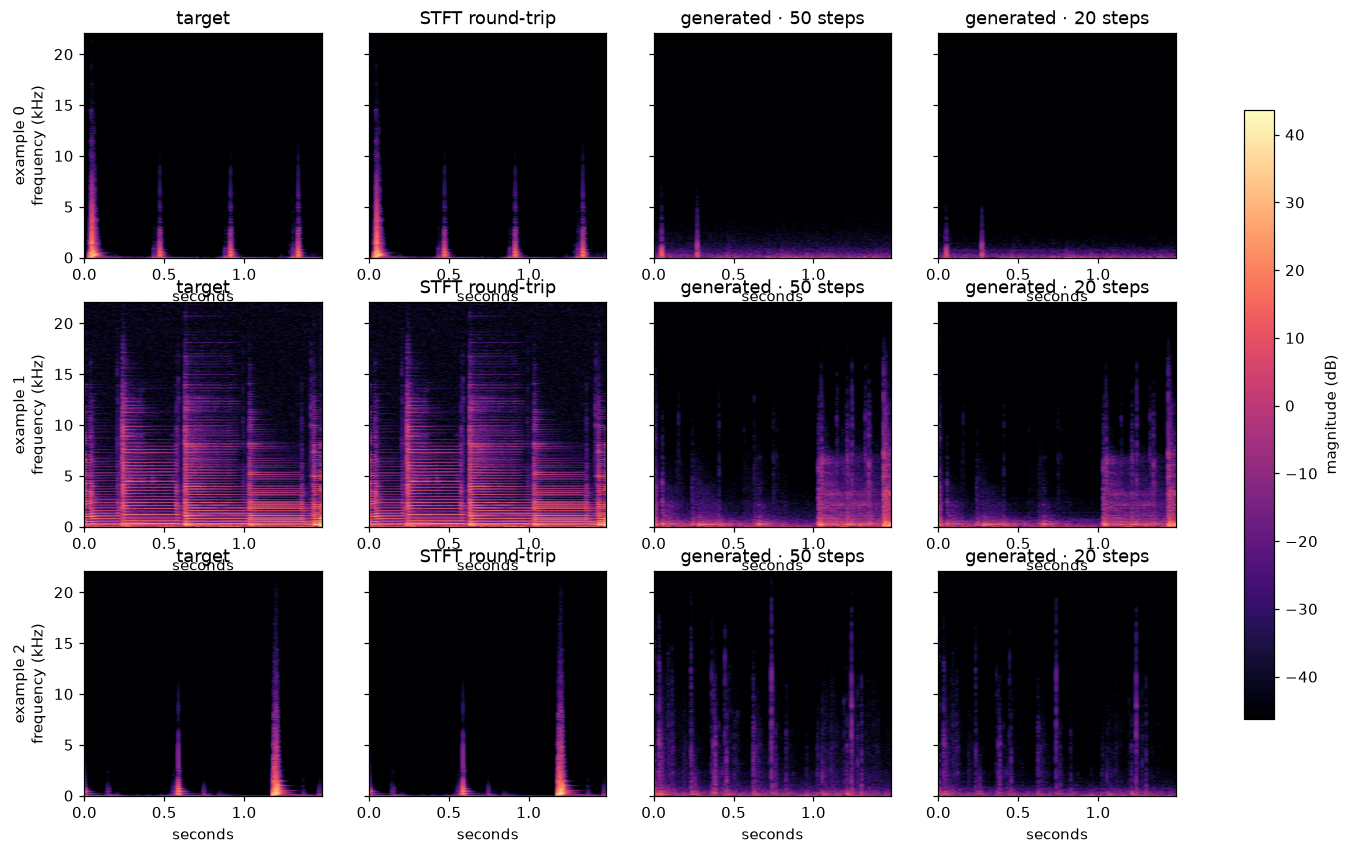

In [20]:
fresh_examples = []
if fresh_results is None:
    print('Fresh comparison skipped.')
else:
    for example_index in range(fresh_results['target'].shape[0]):
        row = [('target', fresh_results['target'][example_index]),
               ('STFT round-trip', fresh_results['stft_roundtrip'][example_index])]
        row += [(f'generated · {steps} steps',
                 fresh_results[f'generated_{steps}'][example_index])
                for steps in SAMPLE_STEPS]
        fresh_examples.append(row)
        display(Markdown(f'### Example {example_index}'))
        for label, waveform in row:
            show_audio(label, waveform, SR)
    plot_spectrogram_grid(
        fresh_examples, SR,
        row_labels=[f'example {i}' for i in range(len(fresh_examples))])

### Compact quantitative comparison

Waveform RMSE is phase-sensitive. Spectral convergence compares linear magnitudes, while log-spectral MAE is an average dB discrepancy. These are diagnostics rather than perceptual scores.

In [21]:
def comparison_metrics(target, estimate):
    target = mono_numpy(target); estimate = mono_numpy(estimate)
    length = min(len(target), len(estimate))
    target, estimate = target[:length], estimate[:length]
    target_spec = 10 ** (spectrogram_db(target) / 20)
    estimate_spec = 10 ** (spectrogram_db(estimate) / 20)
    spectral_convergence = (np.linalg.norm(estimate_spec - target_spec) /
                            max(np.linalg.norm(target_spec), 1e-12))
    return {'waveform_rmse': np.sqrt(np.mean((estimate - target) ** 2)),
            'spectral_convergence': spectral_convergence,
            'log_spectral_mae_db': np.mean(np.abs(
                spectrogram_db(estimate) - spectrogram_db(target))),
            **{f'estimate_{k}': v for k, v in audio_stats(estimate).items()}}

if fresh_results is None:
    print('Fresh metrics skipped.')
else:
    metric_rows = []
    methods = [('STFT round-trip', fresh_results['stft_roundtrip'])] + [
        (f'generated {steps} steps', fresh_results[f'generated_{steps}'])
        for steps in SAMPLE_STEPS]
    for example_index in range(fresh_results['target'].shape[0]):
        for method, estimates in methods:
            metric_rows.append({'example': example_index, 'method': method,
                                **comparison_metrics(
                                    fresh_results['target'][example_index],
                                    estimates[example_index])})
    metrics = pd.DataFrame(metric_rows).set_index(['example', 'method'])
    display(metrics.round(5))
    display(metrics.groupby('method').mean().round(5))

waveform_rmse  spectral_convergence  \
example method                                                    
0       STFT round-trip           0.00002               0.00060   
        generated 50 steps        0.03131               0.92601   
        generated 20 steps        0.03128               0.95717   
1       STFT round-trip           0.00463               0.06241   
        generated 50 steps        0.08620               0.89155   
        generated 20 steps        0.08499               0.90614   
2       STFT round-trip           0.00001               0.00033   
        generated 50 steps        0.03874               0.98276   
        generated 20 steps        0.03848               0.98534   

                            log_spectral_mae_db  estimate_peak  estimate_rms  \
example method                                                                 
0       STFT round-trip                 0.06534        0.90000       0.03126   
        generated 50 steps             10.86800        0.14076       0.00426   
        generated 20 steps             10.53604        0.07390       0.00321   
1       STFT round-trip                 0.12360        0.58659       0.08240   
        generated 50 steps             19.97101        0.26094       0.02422   
        generated 20 steps             23.48361        0.21264       0.01967   
2       STFT round-trip                 0.05799        0.75729       0.03843   
        generated 50 steps             15.93526        0.06152       0.00635   
        generated 20 steps             13.74159        0.03989       0.00380   

                            estimate_clip_%  
example method                               
0       STFT round-trip                 0.0  
        generated 50 steps              0.0  
        generated 20 steps              0.0  
1       STFT round-trip                 0.0  
        generated 50 steps              0.0  
        generated 20 steps              0.0  
2       STFT round-trip                 0.0  
        generated 50 steps              0.0  
        generated 20 steps              0.0

,waveform_rmse,spectral_convergence,log_spectral_mae_db,estimate_peak,estimate_rms,estimate_clip_%
method,,,,,,
STFT round-trip,0.00155,0.02111,0.08231,0.74796,0.05070,0.0
generated 20 steps,0.05158,0.94955,15.92041,0.10881,0.00889,0.0
generated 50 steps,0.05208,0.93344,15.59142,0.15441,0.01161,0.0


## Headline summary

A compact, copyable summary of the selected run. These are diagnostics, not an automatic quality verdict; listening to the logged and fresh samples remains essential.

In [23]:
train_frame = scalar_frame('train/flow_loss')
validation_frame = scalar_frame('validation/flow_loss')
headline = {
    'run': RUN_DIR.name, 'loaded_checkpoint_step': saved_step,
    'parameters': parameter_count,
    'latest_train_step': int(train_frame.step.iloc[-1]) if len(train_frame) else None,
    'latest_train_loss': float(train_frame.value.iloc[-1]) if len(train_frame) else np.nan,
    'latest_validation_step': (int(validation_frame.step.iloc[-1])
                               if len(validation_frame) else None),
    'latest_validation_loss': (float(validation_frame.value.iloc[-1])
                               if len(validation_frame) else np.nan),
    'best_validation_loss': (float(validation_frame.value.min())
                             if len(validation_frame) else np.nan),
    'best_validation_step': (int(validation_frame.loc[validation_frame.value.idxmin(), 'step'])
                             if len(validation_frame) else None),
    # 'input_gain_min': float(input_gains.min()),
    # 'input_gain_max': float(input_gains.max()),
    # 'output_gain_min': float(output_gains.min()),
    # 'output_gain_max': float(output_gains.max()),
}
display(pd.DataFrame.from_dict(headline, orient='index', columns=['value']))
warnings = []
if len(train_frame) and saved_step < int(train_frame.step.iloc[-1]):
    warnings.append(f'Latest logs are {int(train_frame.step.iloc[-1]) - saved_step:,} '
                    'steps newer than the loaded checkpoint.')

display(Markdown('**Automatic flags:** ' +
                 ('  '.join(warnings) if warnings else 'none')))

,value
run,dafter_guitarv7
loaded_checkpoint_step,250000
parameters,11771298
latest_train_step,251800
latest_train_loss,0.224063
latest_validation_step,250000
latest_validation_loss,0.374335
best_validation_loss,0.268497
best_validation_step,215000


**Automatic flags:** Latest logs are 1,800 steps newer than the loaded checkpoint.

## Suggested investigation loop

- Change `RUN_NAME` or `CHECKPOINT_STEP` while keeping `EXAMPLE_SEED` and `NOISE_SEED` fixed for fair comparisons.
- Keep `SAMPLE_STEPS` fixed while comparing checkpoints; keep the shared noise behavior intact.
- Watch raw peak/RMS and the hidden-feature gain heatmaps together. Extreme or negative localized gains can explain unstable bands even when scalar loss improves.
- For a conditioning sanity check, reuse `noise` and replace `midi` with zeros (unconditional) or another example's MIDI, then listen for whether pitch/rhythm follows the conditioning.

## Rectified-flow conditioning diagnostics

These tests reuse the fixed validation crop and checkpoint loaded above. They concentrate resolution near $t=0$, where sampling starts and conditional-mean contraction is most likely. Increase the draw counts for a more stable estimate; the defaults are deliberately lightweight.

In [24]:
DIAGNOSTIC_MAX_EXAMPLES = 2
TIME_BIN_EDGES = np.array([0, .02, .05, .10, .20, .40, .60, .80, .90, .95, .98, 1.0])
TIME_DRAWS_PER_BIN = 2
CONTRACTION_NOISE_DRAWS = 8
TIME_SENSITIVITY_POINTS = (0, .01, .025, .05, .10, .25, .50, .75, 1.0)
TRAJECTORY_STEPS = 20
DIAGNOSTIC_SEED = NOISE_SEED + 1000

def tensor_rms(value: torch.Tensor) -> torch.Tensor:
    return value.float().square().mean().sqrt()

def batch_rms(value: torch.Tensor) -> torch.Tensor:
    return value.float().flatten(1).square().mean(dim=1).sqrt()

def batch_cosine(left: torch.Tensor, right: torch.Tensor) -> torch.Tensor:
    return torch.nn.functional.cosine_similarity(
        left.float().flatten(1), right.float().flatten(1), dim=1)

def diagnostic_autocast():
    return (torch.autocast('cuda', dtype=torch.float16)
            if USE_AMP and str(DEVICE).startswith('cuda') else nullcontext())

diagnostics_ready = fresh_batch is not None
if not diagnostics_ready:
    print('Diagnostics skipped: run the fresh dataset-conditioned sampling setup first.')
else:
    diagnostic_count = min(DIAGNOSTIC_MAX_EXAMPLES, device_batch['midi'].shape[0])
    diagnostic_waveform = device_batch['waveform'][:diagnostic_count]
    diagnostic_midi = device_batch['midi'][:diagnostic_count]
    diagnostic_style = None if style is None else style[:diagnostic_count]
    diagnostic_generator = torch.Generator(device=DEVICE).manual_seed(DIAGNOSTIC_SEED)
    with torch.inference_mode():
        # Whiten the clean endpoint before adding noise, exactly as in training.
        diagnostic_clean = model.audio_to_spectrum(diagnostic_waveform)
    diagnostic_noise = torch.randn(
        diagnostic_clean.shape, generator=diagnostic_generator, device=DEVICE,
        dtype=diagnostic_clean.dtype)
    print(f'Diagnostics use {diagnostic_count} example(s), seed {DIAGNOSTIC_SEED}, '
          f'and {TRAJECTORY_STEPS} trajectory steps.')

Diagnostics use 2 example(s), seed 3026, and 20 trajectory steps.


### Loss stratified by flow time

For each interval, this samples fresh noise and time values while keeping the clean examples and MIDI fixed. Besides MSE, velocity cosine measures direction, and the one-step clean error asks how well $x_t + (1-t)\hat v$ estimates the endpoint.

,sampled_t,mse,velocity_cosine,predicted_velocity_rms,target_velocity_rms,one_step_clean_relative_error,t_start,t_end
bin,,,,,,,,
0,0.01081,1.08333,0.77154,1.00469,1.38932,1.01473,0.00,0.02
1,0.03280,0.98091,0.79861,1.03352,1.38949,0.98011,0.02,0.05
2,0.07947,0.78902,0.84637,1.11092,1.38908,0.86417,0.05,0.10
3,0.15156,0.52698,0.90273,1.22127,1.38846,0.65112,0.10,0.20
4,0.35941,0.25939,0.95398,1.31034,1.38954,0.37963,0.20,0.40
5,0.54291,0.20953,0.96296,1.31815,1.38963,0.25679,0.40,0.60
6,0.68918,0.20069,0.96418,1.32360,1.39040,0.17415,0.60,0.80
7,0.84561,0.21747,0.95977,1.31388,1.38934,0.09897,0.80,0.90
8,0.92495,0.28010,0.94546,1.28363,1.38977,0.06301,0.90,0.95


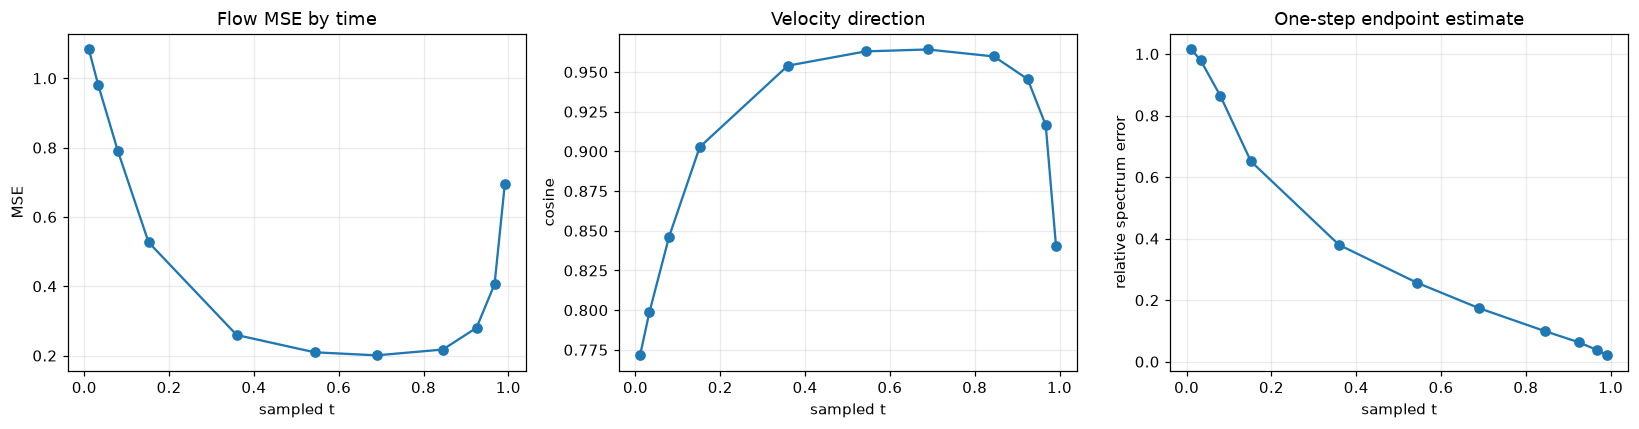

In [25]:
time_loss_table = None
if diagnostics_ready:
    time_loss_rows = []
    loss_generator = torch.Generator(device=DEVICE).manual_seed(DIAGNOSTIC_SEED + 1)
    with torch.inference_mode(), diagnostic_autocast():
        for bin_index, (lower, upper) in enumerate(zip(TIME_BIN_EDGES[:-1],
                                                        TIME_BIN_EDGES[1:])):
            draw_rows = []
            for _ in range(TIME_DRAWS_PER_BIN):
                noise_draw = torch.randn(
                    diagnostic_clean.shape, generator=loss_generator, device=DEVICE,
                    dtype=diagnostic_clean.dtype)
                unit_time = torch.rand(
                    (diagnostic_count, 1), generator=loss_generator, device=DEVICE,
                    dtype=diagnostic_clean.dtype)
                flow_time = lower + (upper - lower) * unit_time
                expanded_time = flow_time[:, :, None, None]
                interpolant = ((1 - expanded_time) * noise_draw +
                               expanded_time * diagnostic_clean)
                target_velocity = diagnostic_clean - noise_draw
                predicted_velocity = model.network(
                    interpolant, diagnostic_midi, diagnostic_style, flow_time)
                mse = (predicted_velocity.float() - target_velocity.float()).square()
                mse = mse.flatten(1).mean(dim=1)
                endpoint_estimate = interpolant + (1 - expanded_time) * predicted_velocity
                endpoint_error = batch_rms(endpoint_estimate - diagnostic_clean) / (
                    batch_rms(diagnostic_clean) + 1e-12)
                draw_rows.append({
                    'sampled_t': float(flow_time.mean()),
                    'mse': float(mse.mean()),
                    'velocity_cosine': float(batch_cosine(
                        predicted_velocity, target_velocity).mean()),
                    'predicted_velocity_rms': float(batch_rms(
                        predicted_velocity).mean()),
                    'target_velocity_rms': float(batch_rms(target_velocity).mean()),
                    'one_step_clean_relative_error': float(endpoint_error.mean()),
                })
            averaged = pd.DataFrame(draw_rows).mean(numeric_only=True).to_dict()
            averaged.update({'bin': bin_index, 't_start': lower, 't_end': upper})
            time_loss_rows.append(averaged)
    time_loss_table = pd.DataFrame(time_loss_rows).set_index('bin')
    display(time_loss_table.round(5))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(time_loss_table.sampled_t, time_loss_table.mse, 'o-')
    axes[0].set(title='Flow MSE by time', xlabel='sampled t', ylabel='MSE')
    axes[1].plot(time_loss_table.sampled_t, time_loss_table.velocity_cosine, 'o-')
    axes[1].set(title='Velocity direction', xlabel='sampled t', ylabel='cosine')
    axes[2].plot(time_loss_table.sampled_t,
                 time_loss_table.one_step_clean_relative_error, 'o-')
    axes[2].set(title='One-step endpoint estimate', xlabel='sampled t',
                ylabel='relative spectrum error')
    for axis in axes:
        axis.grid(alpha=.25)
    plt.tight_layout(); plt.show()

### Contraction test at $t=0$

If the learned field is collapsing toward the conditional mean, its initial velocity will align with $-x_0$. The projection coefficient is 1 for exactly $v=-x_0$; `x0_plus_v_rms` is the model's one-unit endpoint estimate in normalized spectrum space.

In [26]:
contraction_table = None
if diagnostics_ready:
    contraction_rows = []
    contraction_generator = torch.Generator(device=DEVICE).manual_seed(
        DIAGNOSTIC_SEED + 2)
    zero_time = torch.zeros((diagnostic_count, 1), device=DEVICE,
                            dtype=diagnostic_clean.dtype)
    clean_spectrum_rms = float(batch_rms(diagnostic_clean).mean())
    clean_audio_rms = float(batch_rms(diagnostic_waveform).mean())
    with torch.inference_mode(), diagnostic_autocast():
        for draw in range(CONTRACTION_NOISE_DRAWS):
            x0 = torch.randn(
                diagnostic_clean.shape, generator=contraction_generator, device=DEVICE,
                dtype=diagnostic_clean.dtype)
            velocity = model.network(x0, diagnostic_midi, diagnostic_style, zero_time)
            minus_x0 = -x0
            projection = ((velocity.float() * minus_x0.float()).flatten(1).sum(1) /
                          (minus_x0.float().flatten(1).square().sum(1) + 1e-12))
            endpoint = x0 + velocity
            endpoint_audio = model.spectrum_to_audio(endpoint)
            for example_index in range(diagnostic_count):
                contraction_rows.append({
                    'draw': draw, 'example': example_index,
                    'cosine_v_with_minus_x0': float(batch_cosine(
                        velocity[example_index:example_index + 1],
                        minus_x0[example_index:example_index + 1])[0]),
                    'projection_on_minus_x0': float(projection[example_index]),
                    'x0_rms': float(batch_rms(x0[example_index:example_index + 1])[0]),
                    'velocity_rms': float(batch_rms(
                        velocity[example_index:example_index + 1])[0]),
                    'x0_plus_v_rms': float(batch_rms(
                        endpoint[example_index:example_index + 1])[0]),
                    'x0_plus_v_audio_rms': float(batch_rms(
                        endpoint_audio[example_index:example_index + 1])[0]),
                })
    contraction_table = pd.DataFrame(contraction_rows).set_index(['draw', 'example'])
    display(contraction_table.round(5))
    contraction_summary = contraction_table.mean().to_frame('mean')
    contraction_summary.loc['clean_spectrum_rms', 'mean'] = clean_spectrum_rms
    contraction_summary.loc['clean_audio_rms', 'mean'] = clean_audio_rms
    display(contraction_summary.round(5))

cosine_v_with_minus_x0  projection_on_minus_x0   x0_rms  \
draw example                                                            
0    0                       0.99897                 1.01165  0.99801   
     1                       0.99891                 1.01144  0.99989   
1    0                       0.99895                 1.01180  1.00034   
     1                       0.99892                 1.01138  0.99968   
2    0                       0.99896                 1.01184  1.00132   
     1                       0.99872                 1.01154  1.00020   
3    0                       0.99896                 1.01184  1.00009   
     1                       0.99892                 1.01150  1.00136   
4    0                       0.99896                 1.01180  1.00008   
     1                       0.99887                 1.01148  1.00222   
5    0                       0.99897                 1.01178  1.00024   
     1                       0.99892                 1.01183  0.99895   
6    0                       0.99895                 1.01198  1.00080   
     1                       0.99886                 1.01142  0.99913   
7    0                       0.99897                 1.01176  1.00013   
     1                       0.99887                 1.01136  0.99928   

              velocity_rms  x0_plus_v_rms  x0_plus_v_audio_rms  
draw example                                                    
0    0             1.01068        0.04727              0.00568  
     1             1.01244        0.04870              0.00673  
1    0             1.01321        0.04794              0.00586  
     1             1.01215        0.04838              0.00659  
2    0             1.01423        0.04779              0.00579  
     1             1.01304        0.05243              0.00649  
3    0             1.01298        0.04762              0.00588  
     1             1.01397        0.04857              0.00667  
4    0             1.01294        0.04774              0.00584  
     1             1.01488        0.04959              0.00646  
5    0             1.01307        0.04749              0.00584  
     1             1.01186        0.04848              0.00671  
6    0             1.01385        0.04806              0.00617  
     1             1.01168        0.04954              0.00645  
7    0             1.01293        0.04737              0.00588  
     1             1.01177        0.04936              0.00660

,mean
cosine_v_with_minus_x0,0.99892
projection_on_minus_x0,1.01165
x0_rms,1.00011
velocity_rms,1.01285
x0_plus_v_rms,0.04852
x0_plus_v_audio_rms,0.00623
clean_spectrum_rms,0.81491
clean_audio_rms,0.05699


### Time sensitivity test

This keeps the noisy state and MIDI fixed while changing only $t$. It measures the final vector field, internal noise condition, transformer modulation, learned frequency gains, and sensitivity to replacing MIDI with zero.

,noise_level,noise_condition_rms,transformer_modulation_rms,velocity_rms,midi_relative_effect,relative_change_from_t0,cosine_with_t0_output
t,,,,,,,
0.000,1.000,1.12844,2.72634,1.01364,0.0,0.00000,1.00000
0.010,0.990,1.06248,2.57229,1.01429,0.0,0.01731,0.99985
0.025,0.975,1.06940,2.63463,1.02632,0.0,0.03545,0.99946
0.050,0.950,1.08077,2.66808,1.05174,0.0,0.07469,0.99799
0.100,0.900,1.04799,2.51464,1.10699,0.0,0.16047,0.99209
0.250,0.750,0.96740,2.25962,1.21924,0.0,0.53905,0.89632
0.500,0.500,0.81632,2.11361,1.86494,0.0,1.38718,0.66875
0.750,0.250,0.82023,2.03126,3.37407,0.0,2.71345,0.70859
1.000,0.000,0.98119,1.59452,3.18932,0.0,2.76884,0.51384


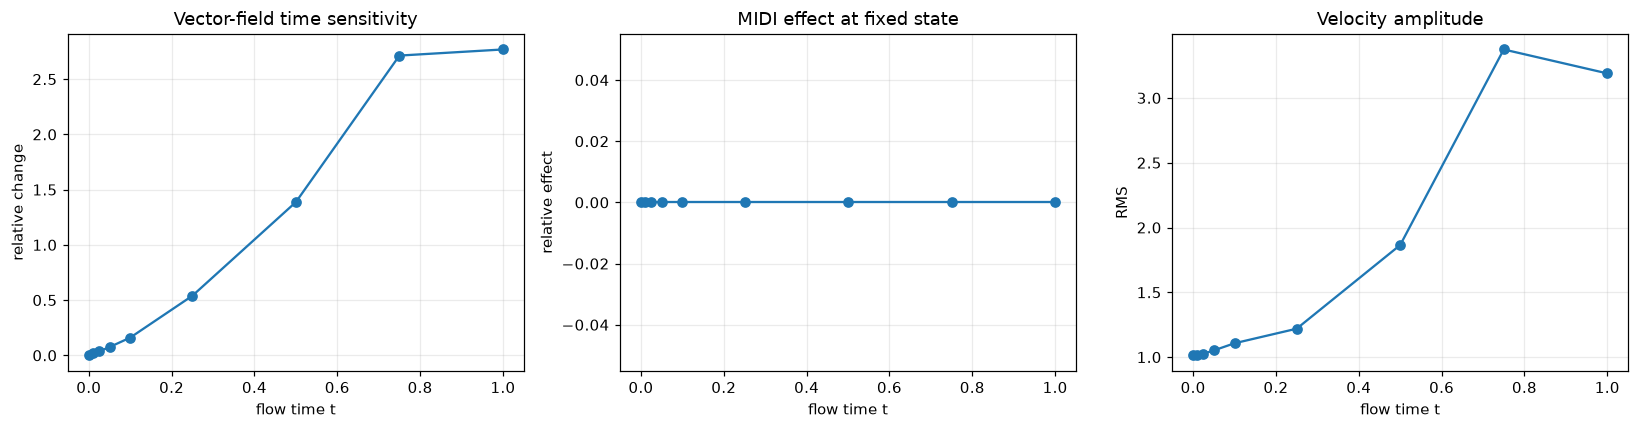

In [27]:
time_sensitivity_table = None
if diagnostics_ready:
    fixed_state = diagnostic_noise[:1]
    fixed_midi = diagnostic_midi[:1]
    fixed_style = None if diagnostic_style is None else diagnostic_style[:1]
    sensitivity_rows, sensitivity_outputs = [], []
    with torch.inference_mode(), diagnostic_autocast():
        for time_value in TIME_SENSITIVITY_POINTS:
            flow_time = torch.full((1, 1), time_value, device=DEVICE,
                                   dtype=fixed_state.dtype)
            condition = (
                model.network._noise_condition_and_frequency_scales(flow_time))
            modulation = torch.cat([
                block.modulation(condition).float().flatten()
                for block in model.network.blocks if block.modulation is not None])
            output = model.network(fixed_state, fixed_midi, fixed_style, flow_time)
            zero_midi_output = model.network(
                fixed_state, torch.zeros_like(fixed_midi), fixed_style, flow_time)
            sensitivity_outputs.append(output.float())
            # input_gain = 1 + input_residual.float()
            # output_gain = 1 + output_residual.float()
            sensitivity_rows.append({
                't': time_value, 'noise_level': 1 - time_value,
                'noise_condition_rms': float(tensor_rms(condition)),
                'transformer_modulation_rms': float(tensor_rms(modulation)),
                'velocity_rms': float(tensor_rms(output)),
                'midi_relative_effect': float(
                    tensor_rms(output - zero_midi_output) / (tensor_rms(output) + 1e-12)),
                # 'input_gain_min': float(input_gain.min()),
                # 'input_gain_median': float(input_gain.median()),
                # 'input_gain_max': float(input_gain.max()),
                # 'output_gain_min': float(output_gain.min()),
                # 'output_gain_median': float(output_gain.median()),
                # 'output_gain_max': float(output_gain.max()),
            })
    reference_output = sensitivity_outputs[0]
    for row, output in zip(sensitivity_rows, sensitivity_outputs):
        row['relative_change_from_t0'] = float(
            tensor_rms(output - reference_output) / (tensor_rms(reference_output) + 1e-12))
        row['cosine_with_t0_output'] = float(batch_cosine(output, reference_output)[0])
    time_sensitivity_table = pd.DataFrame(sensitivity_rows).set_index('t')
    display(time_sensitivity_table.round(5))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(time_sensitivity_table.index,
                 time_sensitivity_table.relative_change_from_t0, 'o-')
    axes[0].set(title='Vector-field time sensitivity', ylabel='relative change')
    axes[1].plot(time_sensitivity_table.index,
                 time_sensitivity_table.midi_relative_effect, 'o-')
    axes[1].set(title='MIDI effect at fixed state', ylabel='relative effect')
    axes[2].plot(time_sensitivity_table.index,
                 time_sensitivity_table.velocity_rms, 'o-')
    axes[2].set(title='Velocity amplitude', ylabel='RMS')
    for axis in axes:
        axis.set_xlabel('flow time t'); axis.grid(alpha=.25)
    plt.tight_layout(); plt.show()

### Short trajectory trace

This reproduces explicit Euler sampling for one example and logs every step. `cosine_v_with_minus_state` reveals contraction, while spectrum and decoded-audio RMS show whether the nonlinear STFT inverse is magnifying amplitude loss.

,evaluated_t,spectrum_rms,target_spectrum_rms,target_relative_spectrum_error,audio_rms,target_audio_rms,audio_peak,velocity_rms,cosine_v_with_minus_state
step,,,,,,,,,
0,NaN,1.00069,0.17825,5.70378,0.06689,0.03126,0.28608,NaN,NaN
1,0.00,0.95006,0.17825,5.42440,0.06364,0.03126,0.27236,1.01364,0.99895
2,0.05,0.90014,0.17825,5.14939,0.06039,0.03126,0.25860,0.99945,0.99905
3,0.10,0.85034,0.17825,4.87561,0.05714,0.03126,0.24461,0.99734,0.99879
4,0.15,0.80061,0.17825,4.60296,0.05389,0.03126,0.23055,0.99704,0.99758
5,0.20,0.75081,0.17825,4.33072,0.05063,0.03126,0.21643,0.99967,0.99650
6,0.25,0.70107,0.17825,4.05976,0.04738,0.03126,0.20224,1.00069,0.99456
7,0.30,0.65142,0.17825,3.79048,0.04413,0.03126,0.18796,1.00072,0.99285
8,0.35,0.60174,0.17825,3.52249,0.04087,0.03126,0.17357,1.00319,0.99113


/tmp/ipykernel_3950296/3844863742.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axis.set_xlabel('Euler step'); axis.grid(alpha=.25); axis.legend()


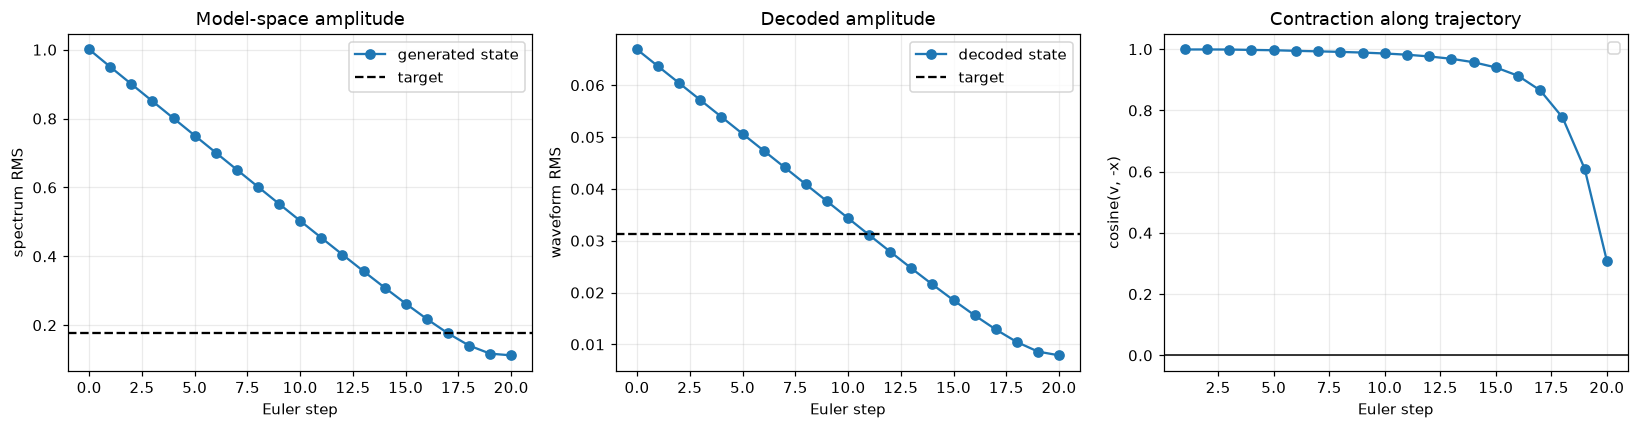

In [28]:
trajectory_table = None
if diagnostics_ready:
    trace_midi = diagnostic_midi[:1]
    trace_style = None if diagnostic_style is None else diagnostic_style[:1]
    trace_clean = diagnostic_clean[:1]
    trace_target_audio = diagnostic_waveform[:1]
    state = diagnostic_noise[:1].clone()
    trajectory_rows = []

    def append_trajectory_row(step, evaluated_t, velocity=None):
        decoded = model.spectrum_to_audio(state)
        row = {
            'step': step, 'evaluated_t': evaluated_t,
            'spectrum_rms': float(tensor_rms(state)),
            'target_spectrum_rms': float(tensor_rms(trace_clean)),
            'target_relative_spectrum_error': float(
                tensor_rms(state - trace_clean) / (tensor_rms(trace_clean) + 1e-12)),
            'audio_rms': float(tensor_rms(decoded)),
            'target_audio_rms': float(tensor_rms(trace_target_audio)),
            'audio_peak': float(decoded.float().abs().max()),
            'velocity_rms': np.nan,
            'cosine_v_with_minus_state': np.nan,
        }
        if velocity is not None:
            row['velocity_rms'] = float(tensor_rms(velocity))
            row['cosine_v_with_minus_state'] = float(
                batch_cosine(velocity, -state)[0])
        trajectory_rows.append(row)

    with torch.inference_mode(), diagnostic_autocast():
        append_trajectory_row(0, np.nan)
        step_size = 1 / TRAJECTORY_STEPS
        for step in range(TRAJECTORY_STEPS):
            time_value = step * step_size
            flow_time = torch.full((1, 1), time_value, device=DEVICE,
                                   dtype=state.dtype)
            velocity = model.network(state, trace_midi, trace_style, flow_time)
            contraction_cosine = float(batch_cosine(velocity, -state)[0])
            velocity_rms = float(tensor_rms(velocity))
            state.add_(step_size * velocity)
            append_trajectory_row(step + 1, time_value)
            trajectory_rows[-1]['velocity_rms'] = velocity_rms
            trajectory_rows[-1]['cosine_v_with_minus_state'] = contraction_cosine

    trajectory_table = pd.DataFrame(trajectory_rows).set_index('step')
    display(trajectory_table.round(5))
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(trajectory_table.index, trajectory_table.spectrum_rms, 'o-',
                 label='generated state')
    axes[0].axhline(float(tensor_rms(trace_clean)), color='black', linestyle='--',
                    label='target')
    axes[0].set(title='Model-space amplitude', ylabel='spectrum RMS')
    axes[1].plot(trajectory_table.index, trajectory_table.audio_rms, 'o-',
                 label='decoded state')
    axes[1].axhline(float(tensor_rms(trace_target_audio)), color='black',
                    linestyle='--', label='target')
    axes[1].set(title='Decoded amplitude', ylabel='waveform RMS')
    axes[2].plot(trajectory_table.index,
                 trajectory_table.cosine_v_with_minus_state, 'o-')
    axes[2].axhline(0, color='black', linewidth=1)
    axes[2].set(title='Contraction along trajectory', ylabel='cosine(v, -x)')
    for axis in axes:
        axis.set_xlabel('Euler step'); axis.grid(alpha=.25); axis.legend()
    plt.tight_layout(); plt.show()

### Phase-versus-magnitude diagnosis

This is the decisive amplitude test. It decodes the four combinations of target/generated raw magnitude and phase, after undoing the nonlinear model-space normalization.

- If **generated magnitude + target phase** becomes much louder than the original generation, generated phase or STFT inconsistency is suppressing the waveform.
- If it remains quiet, generated magnitude/distribution is the primary limitation.
- If **target magnitude + generated phase** stays near target loudness, the generated phase is capable of coherent synthesis and magnitude is the main problem.
- Compare generated consistency error against the target baseline; a much larger value means the generated complex spectrum lies away from the realizable STFT manifold.

In [29]:
phase_diagnostic_table = None
if fresh_results is None:
    print('Phase diagnosis skipped: run fresh dataset-conditioned sampling first.')
else:
    PHASE_DIAGNOSTIC_STEPS = max(SAMPLE_STEPS)
    phase_count = min(DIAGNOSTIC_MAX_EXAMPLES, fresh_results['target'].shape[0])
    target_model_spectrum = fresh_results['target_spectrum'][:phase_count].to(DEVICE)
    generated_model_spectrum = fresh_results[
        f'generated_spectrum_{PHASE_DIAGNOSTIC_STEPS}'][:phase_count].to(DEVICE)

    def complex_unit_phase(value: torch.Tensor) -> torch.Tensor:
        return value / value.abs().clamp_min(1e-12)

    def model_spectrum_with(magnitude_source: torch.Tensor,
                            phase_source: torch.Tensor) -> torch.Tensor:
        hybrid_raw = magnitude_source.abs() * complex_unit_phase(phase_source)
        return pack_model_spectrum(hybrid_raw)

    with torch.inference_mode():
        # unpack_model_spectrum first undoes whitening and then reverses the
        # alpha/beta normalization, so the swap is in the linear STFT domain.
        target_raw_spectrum = unpack_model_spectrum(target_model_spectrum)
        generated_raw_spectrum = unpack_model_spectrum(generated_model_spectrum)
        generated_magnitude_target_phase = model_spectrum_with(
            generated_raw_spectrum, target_raw_spectrum)
        target_magnitude_generated_phase = model_spectrum_with(
            target_raw_spectrum, generated_raw_spectrum)

        phase_audio = {
            'target magnitude + target phase': model.spectrum_to_audio(
                target_model_spectrum),
            'generated magnitude + generated phase': model.spectrum_to_audio(
                generated_model_spectrum),
            'generated magnitude + target phase': model.spectrum_to_audio(
                generated_magnitude_target_phase),
            'target magnitude + generated phase': model.spectrum_to_audio(
                target_magnitude_generated_phase),
        }

        target_projection = model.audio_to_spectrum(
            phase_audio['target magnitude + target phase'])
        generated_projection = model.audio_to_spectrum(
            phase_audio['generated magnitude + generated phase'])
        target_consistency = batch_rms(
            target_projection - target_model_spectrum) / (
                batch_rms(target_model_spectrum) + 1e-12)
        generated_consistency = batch_rms(
            generated_projection - generated_model_spectrum) / (
                batch_rms(generated_model_spectrum) + 1e-12)

    phase_rows = []
    for example_index in range(phase_count):
        rms_values = {name: float(batch_rms(
            waveform[example_index:example_index + 1])[0])
            for name, waveform in phase_audio.items()}
        generated_rms = rms_values['generated magnitude + generated phase']
        target_rms = rms_values['target magnitude + target phase']
        phase_rows.append({
            'example': example_index,
            'target_audio_rms': target_rms,
            'generated_audio_rms': generated_rms,
            'generated_mag_target_phase_rms': rms_values[
                'generated magnitude + target phase'],
            'target_mag_generated_phase_rms': rms_values[
                'target magnitude + generated phase'],
            'phase_recovery_ratio': rms_values[
                'generated magnitude + target phase'] / max(generated_rms, 1e-12),
            'target_mag_with_generated_phase_ratio': rms_values[
                'target magnitude + generated phase'] / max(target_rms, 1e-12),
            'target_consistency_error': float(target_consistency[example_index]),
            'generated_consistency_error': float(
                generated_consistency[example_index]),
        })
    phase_diagnostic_table = pd.DataFrame(phase_rows).set_index('example')
    display(phase_diagnostic_table.round(5))

    display(Markdown(f'#### Phase-swap listening example · {PHASE_DIAGNOSTIC_STEPS} steps'))
    for label, waveform in phase_audio.items():
        show_audio(label, waveform[0], SR)

,target_audio_rms,generated_audio_rms,generated_mag_target_phase_rms,target_mag_generated_phase_rms,phase_recovery_ratio,target_mag_with_generated_phase_ratio,target_consistency_error,generated_consistency_error
example,,,,,,,,
0,0.03126,0.00426,0.00361,0.02581,0.84728,0.82573,0.01007,0.68791
1,0.08240,0.02422,0.02185,0.07241,0.90205,0.87866,0.01836,0.32717


#### Phase-swap listening example · 50 steps

**target magnitude + target phase** — peak 0.900, RMS 0.0313, >1 0.00%

**generated magnitude + generated phase** — peak 0.141, RMS 0.0043, >1 0.00%

**generated magnitude + target phase** — peak 0.044, RMS 0.0036, >1 0.00%

**target magnitude + generated phase** — peak 0.748, RMS 0.0258, >1 0.00%

### Clean-noise interpolation versus generated trajectory

At each matched flow time, this compares the state reached by explicit Euler generation with the state produced directly by the training noising scheme, $x_t=(1-t)\epsilon+t\,W(x_{clean})$, where $W$ is the fitted spectrum whitening transform. Both paths use the same whitened clean endpoints and initial noise, so the comparison is paired. Every displayed RMS is the mean over the diagnostic examples. Ratios below 1 mean that the generated path has less amplitude than the corresponding clean-noise interpolation.

spectrum_rms  audio_rms
step t    path                                         
0    0.00 clean-noise scheme         1.00046    0.06698
          generated trajectory       1.00046    0.06698
1    0.05 clean-noise scheme         0.95183    0.06361
          generated trajectory       0.94985    0.06371
2    0.10 clean-noise scheme         0.90630    0.06040
          generated trajectory       0.90003    0.06052
3    0.15 clean-noise scheme         0.86429    0.05739
          generated trajectory       0.85033    0.05734
4    0.20 clean-noise scheme         0.82624    0.05461
          generated trajectory       0.80071    0.05418
5    0.25 clean-noise scheme         0.79254    0.05208
          generated trajectory       0.75103    0.05105
6    0.30 clean-noise scheme         0.76347    0.04985
          generated trajectory       0.70142    0.04793
7    0.35 clean-noise scheme         0.73921    0.04795
          generated trajectory       0.65192    0.04484
8    0.40 clean-noise scheme         0.71976    0.04639
          generated trajectory       0.60241    0.04175
9    0.45 clean-noise scheme         0.70502    0.04519
          generated trajectory       0.55315    0.03869
10   0.50 clean-noise scheme         0.69473    0.04437
          generated trajectory       0.50401    0.03567
11   0.55 clean-noise scheme         0.68859    0.04394
          generated trajectory       0.45507    0.03270
12   0.60 clean-noise scheme         0.68629    0.04388
          generated trajectory       0.40637    0.02979
13   0.65 clean-noise scheme         0.68754    0.04422
          generated trajectory       0.35795    0.02698
14   0.70 clean-noise scheme         0.69219    0.04493
          generated trajectory       0.31029    0.02430
15   0.75 clean-noise scheme         0.70024    0.04603
          generated trajectory       0.26348    0.02177
16   0.80 clean-noise scheme         0.71196    0.04751
          generated trajectory       0.21814    0.01947
17   0.85 clean-noise scheme         0.72801    0.04935
          generated trajectory       0.17528    0.01745
18   0.90 clean-noise scheme         0.74959    0.05154
          generated trajectory       0.13740    0.01580
19   0.95 clean-noise scheme         0.77820    0.05404
          generated trajectory       0.10996    0.01465
20   1.00 clean-noise scheme         0.81491    0.05683
          generated trajectory       0.10140    0.01433

#### Generated / clean-noise ratios

,,spectrum_rms_generated_to_scheme,audio_rms_generated_to_scheme
step,t,,
0,0.00,1.00000,1.00000
1,0.05,0.99792,1.00164
2,0.10,0.99309,1.00194
3,0.15,0.98385,0.99917
4,0.20,0.96909,0.99227
5,0.25,0.94763,0.98010
6,0.30,0.91873,0.96145
7,0.35,0.88192,0.93514
8,0.40,0.83696,0.90003


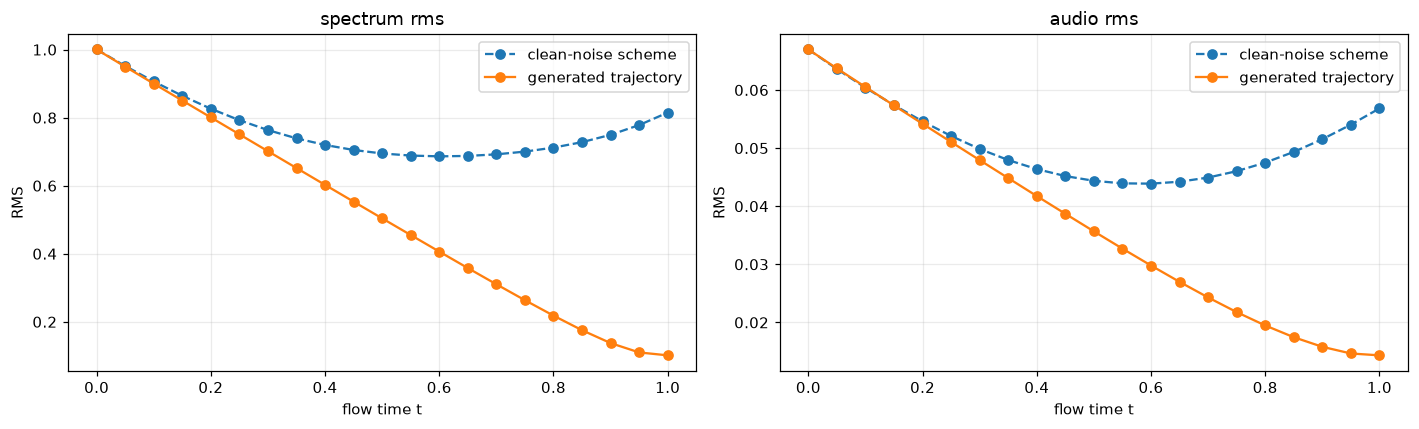

In [30]:
trajectory_state_statistics_examples = None
trajectory_state_statistics_table = None
trajectory_state_statistics_ratios = None
if diagnostics_ready:
    comparison_state = diagnostic_noise.clone()
    comparison_rows = []

    def append_state_statistics(step: int, flow_time: float) -> None:
        clean_noised_state = ((1 - flow_time) * diagnostic_noise +
                               flow_time * diagnostic_clean)
        for path, path_state in (
                ('clean-noise scheme', clean_noised_state),
                ('generated trajectory', comparison_state)):
            decoded = model.spectrum_to_audio(path_state)
            spectrum_rms = batch_rms(path_state)
            audio_rms = batch_rms(decoded)
            for example_index in range(diagnostic_count):
                comparison_rows.append({
                    'step': step, 't': flow_time, 'path': path,
                    'example': example_index,
                    'spectrum_rms': float(spectrum_rms[example_index]),
                    'audio_rms': float(audio_rms[example_index]),
                })

    with torch.inference_mode(), diagnostic_autocast():
        append_state_statistics(0, 0.0)
        step_size = 1 / TRAJECTORY_STEPS
        for step in range(TRAJECTORY_STEPS):
            evaluated_t = step * step_size
            flow_time = torch.full(
                (diagnostic_count, 1), evaluated_t, device=DEVICE,
                dtype=comparison_state.dtype)
            velocity = model.network(
                comparison_state, diagnostic_midi, diagnostic_style, flow_time)
            comparison_state.add_(step_size * velocity)
            append_state_statistics(step + 1, (step + 1) * step_size)

    metric_names = ('spectrum_rms', 'audio_rms')
    trajectory_state_statistics_examples = pd.DataFrame(comparison_rows).set_index(
        ['step', 't', 'path', 'example'])
    trajectory_state_statistics_table = (
        trajectory_state_statistics_examples.groupby(['step', 't', 'path'])
        [list(metric_names)].mean())
    scheme_statistics = trajectory_state_statistics_table.xs(
        'clean-noise scheme', level='path')
    generated_statistics = trajectory_state_statistics_table.xs(
        'generated trajectory', level='path')
    trajectory_state_statistics_ratios = pd.DataFrame({
        f'{metric}_generated_to_scheme':
            generated_statistics[metric] / scheme_statistics[metric].clip(lower=1e-12)
        for metric in metric_names
    })

    display(trajectory_state_statistics_table.round(5))
    display(Markdown('#### Generated / clean-noise ratios'))
    display(trajectory_state_statistics_ratios.round(5))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
    for axis, metric in zip(axes.flat, metric_names):
        for path, linestyle in (('clean-noise scheme', '--'),
                                ('generated trajectory', '-')):
            values = trajectory_state_statistics_table.xs(path, level='path')
            axis.plot(values.index.get_level_values('t'), values[metric],
                      marker='o', linestyle=linestyle, label=path)
        axis.set(title=metric.replace('_', ' '), xlabel='flow time t',
                 ylabel=metric.rsplit('_', 1)[-1].upper())
        axis.grid(alpha=.25)
        axis.legend()
    plt.tight_layout(); plt.show()

rms
step t   path                 band_index band                 
0    0.0 clean-noise scheme   0          0–250 Hz      1.00150
                              1          250–500 Hz    0.99570
                              2          0.5–1 kHz     0.99783
                              3          1–2 kHz       0.99802
                              4          2–4 kHz       0.99781
...                                                        ...
20   1.0 generated trajectory 3          1–2 kHz       0.08521
                              4          2–4 kHz       0.08564
                              5          4–8 kHz       0.09255
                              6          8–16 kHz      0.08737
                              7          16–22.05 kHz  0.11389

[336 rows x 1 columns]

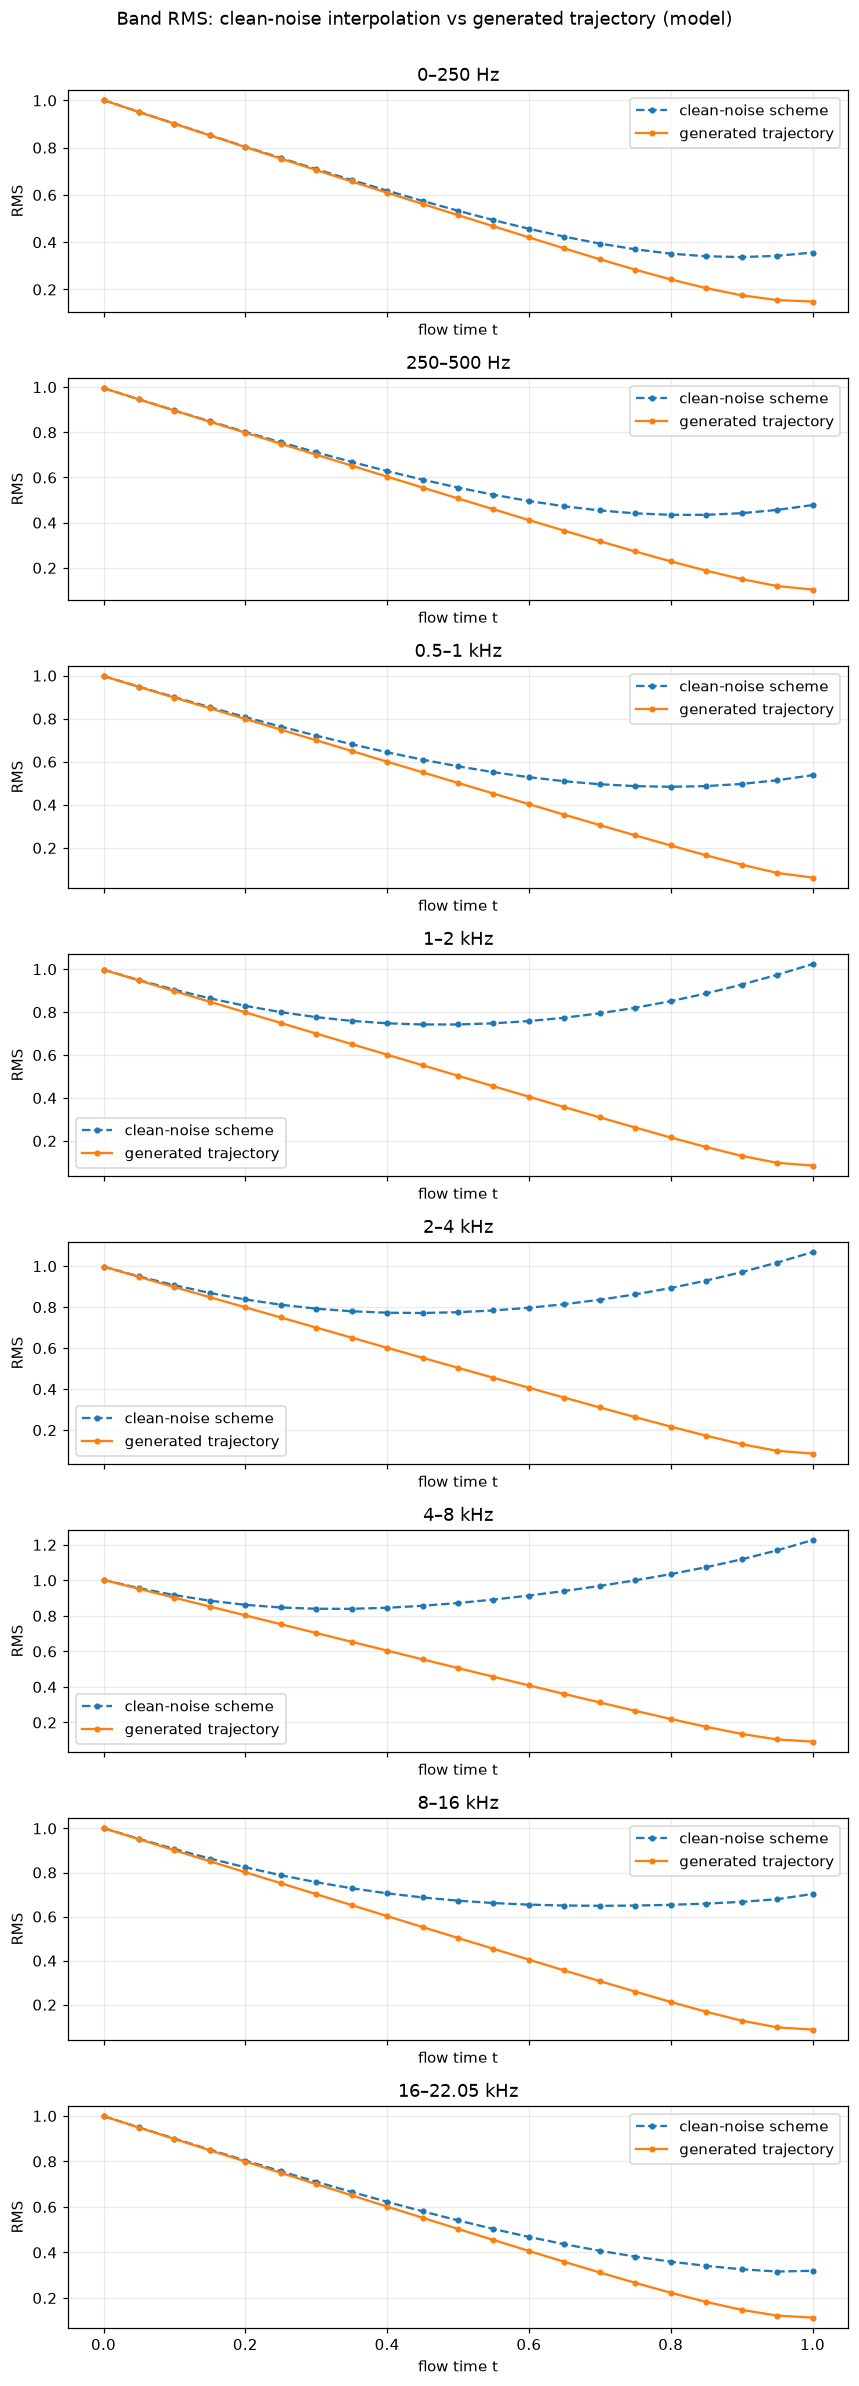

In [31]:
# Frequency-band RMS comparison:
#   "model"            -> packed normalized real/imaginary spectrum
#   "linear_magnitude" -> denormalized linear-STFT magnitude
BAND_DOMAIN = "model"

FREQUENCY_BAND_EDGES_HZ = (
    0,
    250,
    500,
    1_000,
    2_000,
    4_000,
    8_000,
    16_000,
)

frequency_band_examples = None
frequency_band_table = None

if not diagnostics_ready:
    print("Frequency-band comparison skipped: run the diagnostics setup first.")
else:
    nyquist = SR / 2

    band_edges = [
        float(edge)
        for edge in FREQUENCY_BAND_EDGES_HZ
        if 0 <= edge < nyquist
    ]

    if not band_edges or band_edges[0] != 0:
        band_edges.insert(0, 0.0)

    band_edges.append(float(nyquist))

    generated_state = diagnostic_noise.clone()
    band_rows = []

    def band_domain_values(state):
        if BAND_DOMAIN == "model":
            # The model omits the Nyquist bin because skip_features=-1.
            frequencies = torch.fft.rfftfreq(
                NFFT,
                d=1 / SR,
                device=state.device,
            )[:-1]

            # Shape: [batch, real/imag channels, frequency, time]
            values = state.float()

        elif BAND_DOMAIN == "linear_magnitude":
            frequencies = torch.fft.rfftfreq(
                NFFT,
                d=1 / SR,
                device=state.device,
            )

            # Shape: [batch, audio channels, frequency, time]
            # Convert from whitened model coordinates before measuring
            # physical linear-STFT magnitudes.
            values = unpack_model_spectrum(state).abs().float()

        else:
            raise ValueError(
                "BAND_DOMAIN must be 'model' or 'linear_magnitude'"
            )

        if values.shape[2] != frequencies.numel():
            raise RuntimeError(
                f"Got {values.shape[2]} spectrum bins but "
                f"{frequencies.numel()} frequency values"
            )

        return values, frequencies

    def append_frequency_band_statistics(step, t):
        # diagnostic_clean is already whitened, so this is exactly the
        # model-space state distribution used during rectified-flow training.
        clean_noised_state = (
            (1 - t) * diagnostic_noise
            + t * diagnostic_clean
        )

        for path, state in (
            ("clean-noise scheme", clean_noised_state),
            ("generated trajectory", generated_state),
        ):
            values, frequencies = band_domain_values(state)

            for band_index, (low, high) in enumerate(
                zip(band_edges[:-1], band_edges[1:])
            ):
                is_final_band = band_index == len(band_edges) - 2

                if is_final_band:
                    band_mask = (
                        (frequencies >= low)
                        & (frequencies <= high)
                    )
                else:
                    band_mask = (
                        (frequencies >= low)
                        & (frequencies < high)
                    )

                if not band_mask.any():
                    continue

                band_values = values[:, :, band_mask, :].flatten(1)
                rms = band_values.square().mean(dim=1).sqrt()

                if high >= 1_000:
                    band_label = (
                        f"{low / 1_000:g}–{high / 1_000:g} kHz"
                    )
                else:
                    band_label = f"{low:g}–{high:g} Hz"

                for example_index in range(diagnostic_count):
                    band_rows.append({
                        "step": step,
                        "t": t,
                        "path": path,
                        "band_index": band_index,
                        "band": band_label,
                        "example": example_index,
                        "rms": float(rms[example_index]),
                    })

    with torch.inference_mode(), diagnostic_autocast():
        append_frequency_band_statistics(step=0, t=0.0)

        step_size = 1 / TRAJECTORY_STEPS

        for step in range(TRAJECTORY_STEPS):
            evaluated_t = step * step_size

            flow_time = torch.full(
                (diagnostic_count, 1),
                evaluated_t,
                device=DEVICE,
                dtype=generated_state.dtype,
            )

            velocity = model.network(
                generated_state,
                diagnostic_midi,
                diagnostic_style,
                flow_time,
            )

            generated_state.add_(step_size * velocity)

            append_frequency_band_statistics(
                step=step + 1,
                t=(step + 1) * step_size,
            )

    frequency_band_examples = pd.DataFrame(band_rows).set_index(
        [
            "step",
            "t",
            "path",
            "band_index",
            "band",
            "example",
        ]
    )

    frequency_band_table = (
        frequency_band_examples
        .groupby(
            ["step", "t", "path", "band_index", "band"]
        )[["rms"]]
        .mean()
    )

    display(frequency_band_table.round(5))

    ordered_bands = (
        frequency_band_table
        .reset_index()[["band_index", "band"]]
        .drop_duplicates()
        .sort_values("band_index")
    )

    fig, axes = plt.subplots(
        len(ordered_bands),
        1,
        figsize=(8, 2.7 * len(ordered_bands)),
        sharex=True,
        squeeze=False,
    )

    path_styles = {
        "clean-noise scheme": "--",
        "generated trajectory": "-",
    }

    for row_index, band_row in enumerate(
        ordered_bands.itertuples()
    ):
        axis = axes[row_index, 0]

        for path, linestyle in path_styles.items():
            values = frequency_band_table.xs(
                (path, band_row.band_index),
                level=("path", "band_index"),
            )

            axis.plot(
                values.index.get_level_values("t"),
                values["rms"],
                marker="o",
                markersize=3,
                linestyle=linestyle,
                label=path,
            )

        axis.set_title(band_row.band)
        axis.set_xlabel("flow time t")
        axis.set_ylabel("RMS")
        axis.grid(alpha=0.25)
        axis.legend()

    fig.suptitle(
        "Band RMS: clean-noise interpolation vs generated trajectory "
        f"({BAND_DOMAIN})",
        y=1.002,
    )

    plt.tight_layout()
    plt.show()